# **EDA previo a exp1v21 - ChestX-ray14**
---
- Caracterizar el dataset NIH ChestX-ray14 completo (14 patologías + No Finding)
- Auditar el split actual del pipeline y proponer una alternativa 70/15/15 a nivel paciente
- Analizar las predicciones del checkpoint exp1v20 por clase sobre el conjunto de validación
- Justificar con evidencia empírica el subset de clases objetivo para exp1v21

El subset de clases elegido (5, 6, 7 o 14) es un resultado del EDA, no una premisa.

## **Imports y constantes**

In [1]:
import os
import gc
import json
import sys
import time
import warnings
import random
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
)

import torch

warnings.filterwarnings("ignore")

SEED = 67
IMG_SIZE = 384
BATCH_SIZE = 32
NUM_WORKERS = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FIGS_DIR = Path("/workspace/figs/v21")
FIGS_DIR.mkdir(parents=True, exist_ok=True)

PALETA = {
    "azul": "#4C72B0",
    "verde": "#55A868",
    "rojo": "#C44E52",
    "gris": "#8C8C8C",
    "amarillo": "#CCB974",
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Device: {DEVICE}")
print(f"Seed: {SEED}")
print(f"Figures dir: {FIGS_DIR}")

Device: cuda
Seed: 67
Figures dir: /workspace/figs/v21


## **Sección 1. Carga del dataset completo**

Buscamos `Data_Entry_2017.csv` en las rutas conocidas. En la instancia Vast.ai
el dataset queda en `/workspace/chestxray/` tras `run_eda.sh`.

In [2]:
POSSIBLE_ROOTS = [
    Path("/workspace/chestxray"),
    Path("/kaggle/input/data"),
    Path("/kaggle/input/nih-chest-xrays/data"),
    Path(os.path.expanduser("~/martin-moe/data/cxr14_raw")),
]

data_root = next((p for p in POSSIBLE_ROOTS if p.exists()), None)
assert data_root, f"Dataset no encontrado en: {[str(p) for p in POSSIBLE_ROOTS]}"

csv_path = next(data_root.glob("Data_Entry*.csv"), None)
if csv_path is None:
    csv_path = next(data_root.rglob("Data_Entry*.csv"))

df = pd.read_csv(csv_path)

# Eliminar columnas artefacto del CSV generadas por una coma sobrante en el
# header de Data_Entry_2017.csv (ej. "Unnamed: 11"). Se hace al principio
# para que el resto del EDA opere sobre un DataFrame limpio.
cols_artefacto = [c for c in df.columns if c.startswith("Unnamed")]
if cols_artefacto:
    print(f"Columnas artefacto eliminadas: {cols_artefacto}")
    df = df.drop(columns=cols_artefacto)

# El header oficial de NIH parte "OriginalImage[Width,Height]" y
# "OriginalImagePixelSpacing[x,y]" en dos columnas con brackets sueltos.
# Renombramos a nombres usables desde Python.
rename_map = {
    "OriginalImage[Width": "OriginalImage_Width",
    "Height]": "OriginalImage_Height",
    "OriginalImagePixelSpacing[x": "PixelSpacing_x",
    "y]": "PixelSpacing_y",
}
renombradas = {k: v for k, v in rename_map.items() if k in df.columns}
if renombradas:
    print(f"Columnas renombradas: {renombradas}")
    df = df.rename(columns=renombradas)

print(f"Registros CSV: {len(df)}")
print(f"Columnas: {list(df.columns)}")
print(f"Pacientes únicos: {df['Patient ID'].nunique()}")
df.head()

Columnas artefacto eliminadas: ['Unnamed: 11']
Columnas renombradas: {'OriginalImage[Width': 'OriginalImage_Width', 'Height]': 'OriginalImage_Height', 'OriginalImagePixelSpacing[x': 'PixelSpacing_x', 'y]': 'PixelSpacing_y'}
Registros CSV: 112120
Columnas: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage_Width', 'OriginalImage_Height', 'PixelSpacing_x', 'PixelSpacing_y']
Pacientes únicos: 30805


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage_Width,OriginalImage_Height,PixelSpacing_x,PixelSpacing_y
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143


### **Exploración de valores únicos por columna**

Antes de construir el target, verificamos cardinalidad, tipo y faltantes
de cada columna del CSV para detectar anomalías de parsing (espacios,
mayúsculas, valores centinela, etc.) que podrían sesgar el modelado.

In [3]:
MAX_MOSTRAR = 10  # si la columna tiene más, se muestra una muestra aleatoria

resumen_cols = []
for col in df.columns:
    uniques = df[col].dropna().unique()
    n_unique = int(df[col].nunique(dropna=False))

    if len(uniques) <= MAX_MOSTRAR:
        muestra_vals = list(uniques)
        sufijo = ""
    else:
        rng = np.random.default_rng(SEED)
        idx = sorted(rng.choice(len(uniques), size=MAX_MOSTRAR, replace=False))
        muestra_vals = [uniques[i] for i in idx]
        sufijo = f"  ... (+{len(uniques) - MAX_MOSTRAR} más)"

    muestra_str = ", ".join(str(v)[:40] for v in muestra_vals) + sufijo
    resumen_cols.append({
        "columna": col,
        "dtype": str(df[col].dtype),
        "n_unique": n_unique,
        "n_missing": int(df[col].isna().sum()),
        "muestra_valores": muestra_str,
    })

df_cols = pd.DataFrame(resumen_cols)
pd.set_option("display.max_colwidth", 200)
df_cols

,columna,dtype,n_unique,n_missing,muestra_valores
0,Image Index,object,112120,0,"00003685_004.png, 00008741_001.png, 00011870_005.png, 00012628_056.png, 00014280_002.png, 00015530_009.png, 00016568_052.png, 00017049_001.png, 00020110_000.png, 00021700_002.png ... (+112110 más)"
1,Finding Labels,object,836,0,"Cardiomegaly|Effusion|Infiltration, Fibrosis|Infiltration|Mass|Nodule, Atelectasis|Fibrosis|Nodule, Cardiomegaly|Effusion|Infiltration|Pneum, Atelectasis|Hernia|Mass, Atelectasis|Emphysema|Infiltr..."
2,Follow-up #,int64,184,0,"22, 54, 72, 79, 92, 98, 110, 111, 133, 136 ... (+174 más)"
3,Patient ID,int64,30805,0,"3910, 9156, 12761, 13696, 15832, 17219, 18423, 18983, 22458, 24108 ... (+30795 más)"
4,Patient Age,int64,107,0,"73, 72, 51, 42, 85, 34, 43, 28, 20, 16 ... (+97 más)"
5,Patient Gender,object,2,0,"M, F"
6,View Position,object,2,0,"PA, AP"
7,OriginalImage_Width,int64,904,0,"2630, 2804, 2324, 1790, 2652, 1737, 2102, 2182, 2232, 2899 ... (+894 más)"
8,OriginalImage_Height,int64,1137,0,"2521, 2421, 2728, 2217, 2183, 2902, 2566, 2775, 2208, 1489 ... (+1127 más)"
9,PixelSpacing_x,float64,23,0,"0.171, 0.194308, 0.1988, 0.171001, 0.193754, 0.194317, 0.194329, 0.194323, 0.194304, 0.185433 ... (+13 más)"


### **Etiquetas multilabel**

`Finding Labels` contiene una o más patologías separadas por `|`. Construimos
14 columnas binarias para las patologías oficiales + una columna `No_Finding`.

In [4]:
PATOLOGIAS_14 = [
    "Atelectasis",
    "Cardiomegaly",
    "Effusion",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax",
    "Consolidation",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Pleural_Thickening",
    "Hernia",
]

for pat in PATOLOGIAS_14:
    df[pat] = df["Finding Labels"].apply(
        lambda x, p=pat: int(p in str(x).split("|"))
    )
df["No_Finding"] = (df["Finding Labels"] == "No Finding").astype(int)
df["n_patologias"] = df[PATOLOGIAS_14].sum(axis=1)

In [5]:
n_nf_csv = int(df["No_Finding"].sum())
n_con_pat = int((df["n_patologias"] > 0).sum())
n_sin_pat = int((df["n_patologias"] == 0).sum())
pct_nf = 100 * n_nf_csv / len(df)
pct_pat = 100 * n_con_pat / len(df)

print(f"Imágenes totales:            {len(df):,}")
print(f"Imágenes con >=1 patología:  {n_con_pat:,}   ({pct_pat:.2f} %)")
print(f"Imágenes No Finding (CSV):   {n_nf_csv:,}   ({pct_nf:.2f} %)")
print(f"Imágenes con 0 patologías:   {n_sin_pat:,}")
print()

# La columna 'No Finding' del CSV debe coincidir exactamente con las imágenes
# que NO tienen ninguna de las 14 patologías marcadas. Si esto no se cumple,
# algún parseo de 'Finding Labels' está mal y el target binario por clase
# quedaría sesgado.
consistente = (df["No_Finding"] == (df["n_patologias"] == 0)).all()
if consistente:
    print("OK - La columna 'No Finding' del CSV es equivalente a n_patologias==0.")
    print("     No hay imágenes con 'No Finding' que simultáneamente reporten")
    print("     patologías, ni imágenes con 0 patologías sin marcar 'No Finding'.")
    print("     El CSV es coherente para construir el target multi-etiqueta.")
else:
    discrep = df[df["No_Finding"] != (df["n_patologias"] == 0)]
    print(f"AVISO: {len(discrep)} filas con discrepancia. Revisar antes de entrenar.")

Imágenes totales:            112,120
Imágenes con >=1 patología:  51,759   (46.16 %)
Imágenes No Finding (CSV):   60,361   (53.84 %)
Imágenes con 0 patologías:   60,361

OK - La columna 'No Finding' del CSV es equivalente a n_patologias==0.
     No hay imágenes con 'No Finding' que simultáneamente reporten
     patologías, ni imágenes con 0 patologías sin marcar 'No Finding'.
     El CSV es coherente para construir el target multi-etiqueta.


### **Partición No Finding vs patología**

Representamos visualmente la división del dataset según la presencia o
ausencia de alguna de las 14 patologías. Refuerza el chequeo anterior:
si la partición suma exactamente el total de imágenes, el target binario
"tiene cualquier patología" queda bien definido para auxiliares como la
cabeza binaria de exp1v18.

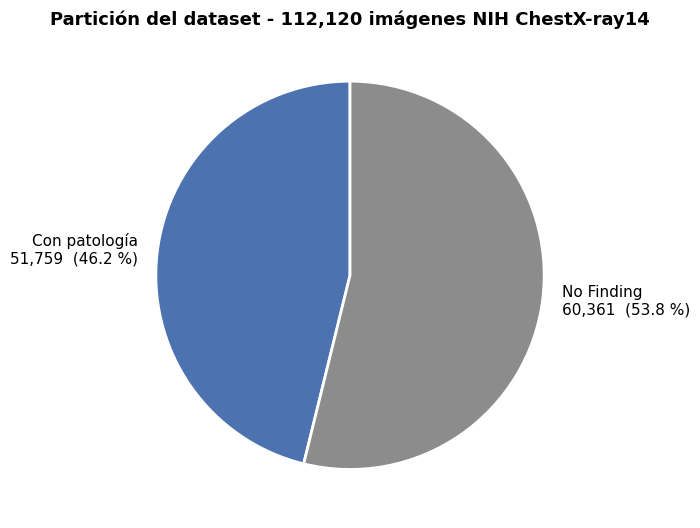

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
sizes = [n_con_pat, n_nf_csv]
labels = [
    f"Con patología\n{n_con_pat:,}  ({pct_pat:.1f} %)",
    f"No Finding\n{n_nf_csv:,}  ({pct_nf:.1f} %)",
]
colores = [PALETA["azul"], PALETA["gris"]]
ax.pie(
    sizes, labels=labels, colors=colores,
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(fontsize=11),
)
ax.set_title(
    f"Partición del dataset - {len(df):,} imágenes NIH ChestX-ray14",
    fontweight="bold", fontsize=13,
)
plt.tight_layout()
plt.savefig(FIGS_DIR / "01_particion_no_finding.png", dpi=120, bbox_inches="tight")
plt.show()

## **Sección 2. Distribución de clases (14 + No Finding)**

Conteos globales, porcentaje, ratio negativos sobre positivos. Incluimos
`No Finding` aparte para contextualizar la distribución multilabel.

In [7]:
conteos = {pat: int(df[pat].sum()) for pat in PATOLOGIAS_14}
conteos["No_Finding"] = int(df["No_Finding"].sum())

df_dist = pd.DataFrame(
    {"clase": list(conteos.keys()), "positivos": list(conteos.values())}
)
df_dist["total"] = len(df)
df_dist["%positivos"] = 100 * df_dist["positivos"] / df_dist["total"]
df_dist["ratio_neg_pos"] = (df_dist["total"] - df_dist["positivos"]) / np.maximum(
    df_dist["positivos"], 1
)
df_dist = df_dist.sort_values("positivos", ascending=False).reset_index(drop=True)
df_dist.round(2)

,clase,positivos,total,%positivos,ratio_neg_pos
0,No_Finding,60361,112120,53.84,0.86
1,Infiltration,19894,112120,17.74,4.64
2,Effusion,13317,112120,11.88,7.42
3,Atelectasis,11559,112120,10.31,8.70
4,Nodule,6331,112120,5.65,16.71
5,Mass,5782,112120,5.16,18.39
6,Pneumothorax,5302,112120,4.73,20.15
7,Consolidation,4667,112120,4.16,23.02
8,Pleural_Thickening,3385,112120,3.02,32.12
9,Cardiomegaly,2776,112120,2.48,39.39


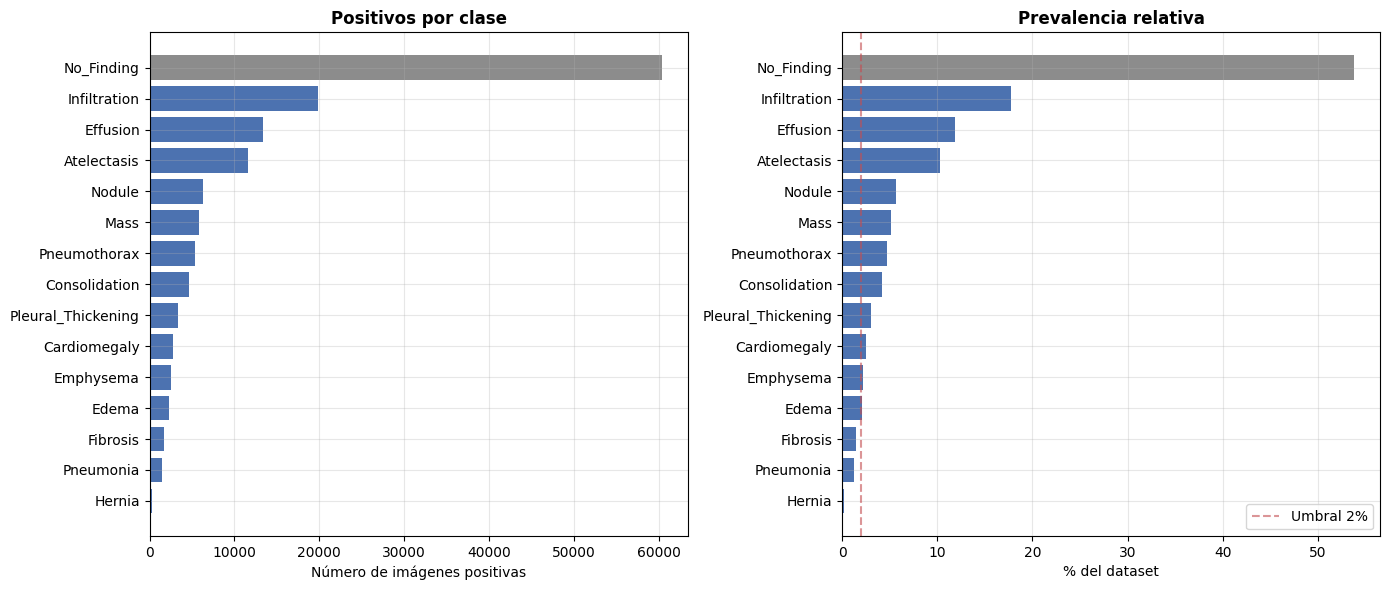

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colores = [PALETA["gris"] if c == "No_Finding" else PALETA["azul"]
           for c in df_dist["clase"]]
axes[0].barh(df_dist["clase"], df_dist["positivos"], color=colores)
axes[0].set_xlabel("Número de imágenes positivas")
axes[0].set_title("Positivos por clase", fontweight="bold")
axes[0].grid(True, alpha=0.3)
axes[0].invert_yaxis()

axes[1].barh(df_dist["clase"], df_dist["%positivos"], color=colores)
axes[1].axvline(2.0, color=PALETA["rojo"], linestyle="--", alpha=0.6,
                label="Umbral 2%")
axes[1].set_xlabel("% del dataset")
axes[1].set_title("Prevalencia relativa", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGS_DIR / "02_distribucion_clases.png", dpi=120, bbox_inches="tight")
plt.show()

### **Etiquetas por imagen**

Cuántas patologías co-ocurren en promedio por imagen. Las imágenes con 0
patologías son `No Finding`.

Número de patologías por imagen:
n_patologias
0    60361
1    30963
2    14306
3     4856
4     1247
5      301
6       67
7       16
8        1
9        2
Name: count, dtype: int64


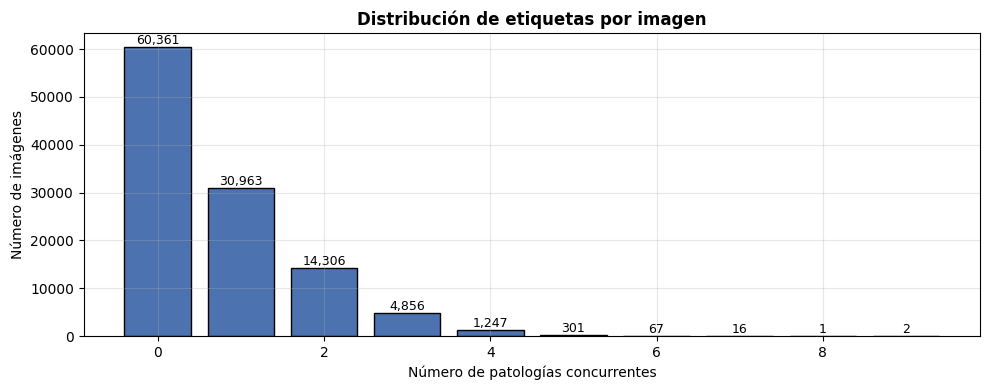

In [9]:
conteo_npat = df["n_patologias"].value_counts().sort_index()
print("Número de patologías por imagen:")
print(conteo_npat)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(conteo_npat.index, conteo_npat.values, color=PALETA["azul"],
       edgecolor="black")
ax.set_xlabel("Número de patologías concurrentes")
ax.set_ylabel("Número de imágenes")
ax.set_title("Distribución de etiquetas por imagen", fontweight="bold")
ax.grid(True, alpha=0.3)
for i, v in enumerate(conteo_npat.values):
    ax.text(conteo_npat.index[i], v, f"{v:,}", ha="center", va="bottom",
            fontsize=9)
plt.tight_layout()
plt.savefig(FIGS_DIR / "02_etiquetas_por_imagen.png", dpi=120, bbox_inches="tight")
plt.show()

### **Exclusión de imágenes con multilabel extremo**

Algunas muestras concentran 5 o más patologías simultáneas. Son casos
severos (UCI, deterioro agudo) que aportan señal clínica real pero también
ruido al gradiente por varios frentes: combinaciones únicas que la red ve
una sola vez, posible etiquetado NLP-mined en cascada (el reporte mencionó
muchas patologías y el parser marcó todas), y sesgo hacia pacientes con
follow-up extenso. Aquí NO decidimos si excluirlas; cuantificamos la
fracción del dataset afectada, la pérdida por clase y el impacto en
pacientes únicos para que la decisión sea auditable.

In [10]:
for k_excl in [5, 6]:
    mask_keep = df["n_patologias"] < k_excl
    mask_drop = ~mask_keep

    n_drop = int(mask_drop.sum())
    pct_drop = 100 * n_drop / len(df)
    pac_drop = df.loc[mask_drop, "Patient ID"].nunique()
    pac_total = df["Patient ID"].nunique()

    print(f"\n--- Escenario: excluir imágenes con n_patologias >= {k_excl} ---")
    print(f"Imágenes eliminadas: {n_drop:,} / {len(df):,} ({pct_drop:.2f} %)")
    print(f"Pacientes afectados (alguna imagen excluida): "
          f"{pac_drop:,} / {pac_total:,} ({100 * pac_drop / pac_total:.2f} %)")

    perdida_clase = []
    for pat in PATOLOGIAS_14:
        pos_total = int(df[pat].sum())
        pos_drop = int(df.loc[mask_drop, pat].sum())
        pct_perdida = 100 * pos_drop / max(pos_total, 1)
        perdida_clase.append({
            "clase": pat,
            "positivos_total": pos_total,
            "positivos_eliminados": pos_drop,
            "pct_perdida": pct_perdida,
            "positivos_restantes": pos_total - pos_drop,
        })
    tabla_perdida = (
        pd.DataFrame(perdida_clase)
        .sort_values("pct_perdida", ascending=False)
        .reset_index(drop=True)
    )
    print(tabla_perdida.to_string(
        index=False,
        formatters={"pct_perdida": "{:.2f}".format},
    ))


--- Escenario: excluir imágenes con n_patologias >= 5 ---
Imágenes eliminadas: 387 / 112,120 (0.35 %)
Pacientes afectados (alguna imagen excluida): 286 / 30,805 (0.93 %)
             clase  positivos_total  positivos_eliminados pct_perdida  positivos_restantes
Pleural_Thickening             3385                   158        4.67                 3227
     Consolidation             4667                   206        4.41                 4461
              Mass             5782                   222        3.84                 5560
      Cardiomegaly             2776                    96        3.46                 2680
             Edema             2303                    71        3.08                 2232
         Pneumonia             1431                    41        2.87                 1390
         Emphysema             2516                    69        2.74                 2447
            Nodule             6331                   165        2.61                 6166
          

In [11]:
combos_por_nivel = (
    df.groupby("n_patologias")["Finding Labels"]
    .nunique()
    .reset_index(name="n_combinaciones_unicas")
)
print("Combinaciones únicas de Finding Labels por nivel de n_patologias:")
print(combos_por_nivel.to_string(index=False))

# Combinaciones que aparecen SOLO con >=5 patologías (no existen en ningún
# registro con <5 patologías). Si son pocas y muy repetidas, la pérdida
# estructural de excluirlas es mínima; si son casi todas únicas, excluir
# borra comorbilidades que el modelo solo puede aprender aquí.
combos_extremos = set(df.loc[df["n_patologias"] >= 5, "Finding Labels"].unique())
combos_menores = set(df.loc[df["n_patologias"] < 5, "Finding Labels"].unique())
combos_solo_extremos = combos_extremos - combos_menores
print(f"\nCombinaciones únicas en n>=5: {len(combos_extremos)}")
print(f"De ellas, combinaciones que NO aparecen con n<5: "
      f"{len(combos_solo_extremos)}")

pacientes_extremos = df.loc[df["n_patologias"] >= 5, "Patient ID"].value_counts()
print(f"\nPacientes con alguna imagen >=5 patologías: {len(pacientes_extremos)}")
print(f"Imágenes por paciente en ese grupo: "
      f"median={pacientes_extremos.median():.1f} "
      f"max={pacientes_extremos.max()} "
      f"p95={np.percentile(pacientes_extremos, 95):.1f}")

Combinaciones únicas de Finding Labels por nivel de n_patologias:
 n_patologias  n_combinaciones_unicas
            0                       1
            1                      14
            2                     101
            3                     253
            4                     262
            5                     145
            6                      43
            7                      14
            8                       1
            9                       2

Combinaciones únicas en n>=5: 205
De ellas, combinaciones que NO aparecen con n<5: 205

Pacientes con alguna imagen >=5 patologías: 286
Imágenes por paciente en ese grupo: median=1.0 max=5 p95=3.0


## **Sección 3. Matriz de co-ocurrencia 14 x 14**

Para cada par de clases, `P(columna | fila)`: dado que la imagen tiene la
patología fila, qué proporción también tiene la patología columna.

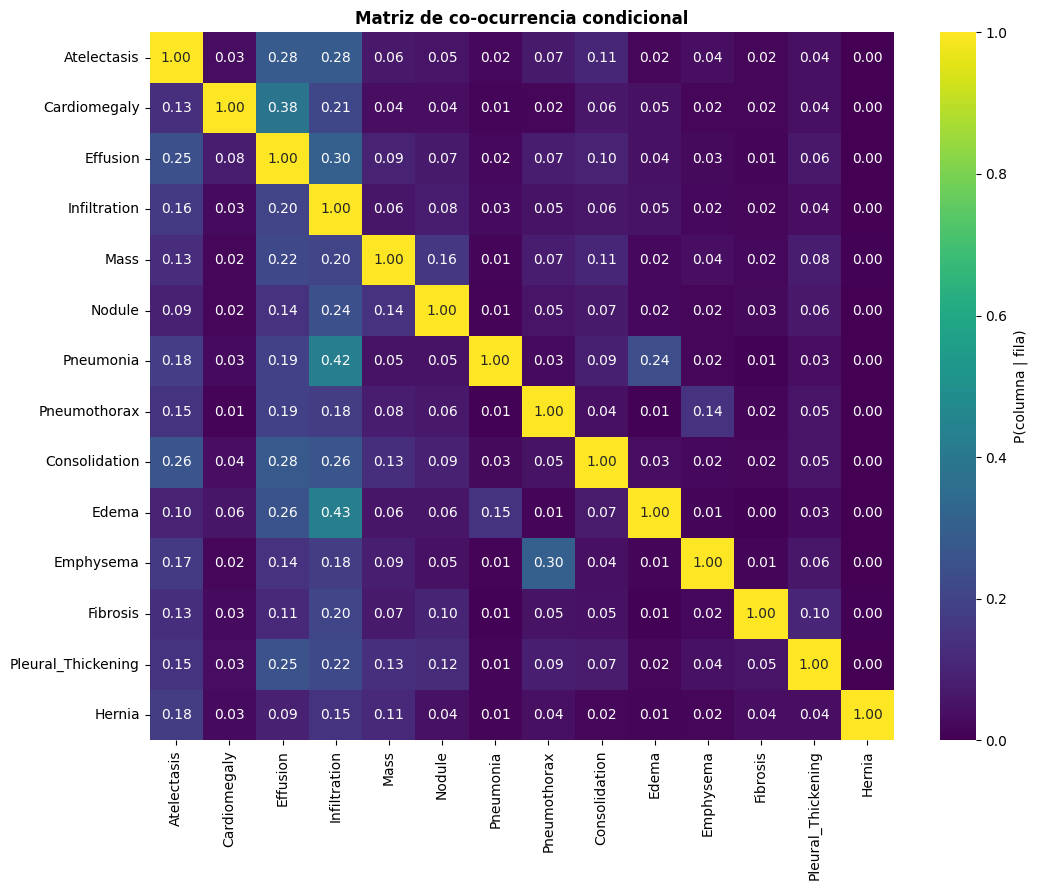

In [12]:
cooc = np.zeros((14, 14), dtype=np.float32)
labels_14 = df[PATOLOGIAS_14].values

for i in range(14):
    mask_i = labels_14[:, i] == 1
    n_i = int(mask_i.sum())
    if n_i > 0:
        for j in range(14):
            cooc[i, j] = labels_14[mask_i, j].sum() / n_i

cooc_df = pd.DataFrame(cooc, index=PATOLOGIAS_14, columns=PATOLOGIAS_14)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cooc_df, annot=True, fmt=".2f", cmap="viridis", ax=ax,
    cbar_kws={"label": "P(columna | fila)"}, vmin=0, vmax=1
)
ax.set_title("Matriz de co-ocurrencia condicional", fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS_DIR / "03_cooc_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

### **Top pares con co-ocurrencia alta**

In [13]:
pares = []
for i, a in enumerate(PATOLOGIAS_14):
    for j, b in enumerate(PATOLOGIAS_14):
        if i < j:
            pares.append(
                (a, b, float(cooc[i, j]), float(cooc[j, i]))
            )
df_pares = pd.DataFrame(
    pares, columns=["clase_a", "clase_b", "P(b|a)", "P(a|b)"]
)
df_pares["max_cooc"] = df_pares[["P(b|a)", "P(a|b)"]].max(axis=1)
df_pares = df_pares.sort_values("max_cooc", ascending=False).reset_index(drop=True)
print("Top 15 pares con co-ocurrencia más alta:")
df_pares.head(15).round(3)

Top 15 pares con co-ocurrencia más alta:


,clase_a,clase_b,P(b|a),P(a|b),max_cooc
0,Infiltration,Edema,0.049,0.426,0.426
1,Infiltration,Pneumonia,0.030,0.423,0.423
2,Cardiomegaly,Effusion,0.383,0.080,0.383
3,Effusion,Infiltration,0.300,0.201,0.300
4,Pneumothorax,Emphysema,0.141,0.297,0.297
5,Atelectasis,Effusion,0.283,0.246,0.283
6,Atelectasis,Infiltration,0.282,0.164,0.282
7,Effusion,Consolidation,0.097,0.276,0.276
8,Atelectasis,Consolidation,0.106,0.262,0.262
9,Infiltration,Consolidation,0.061,0.262,0.262


## **Sección 4. Pacientes e imágenes por paciente**

Pacientes únicos: 30805
Imágenes totales: 112120
Imágenes por paciente: min=1, median=1, mean=3.6, max=184


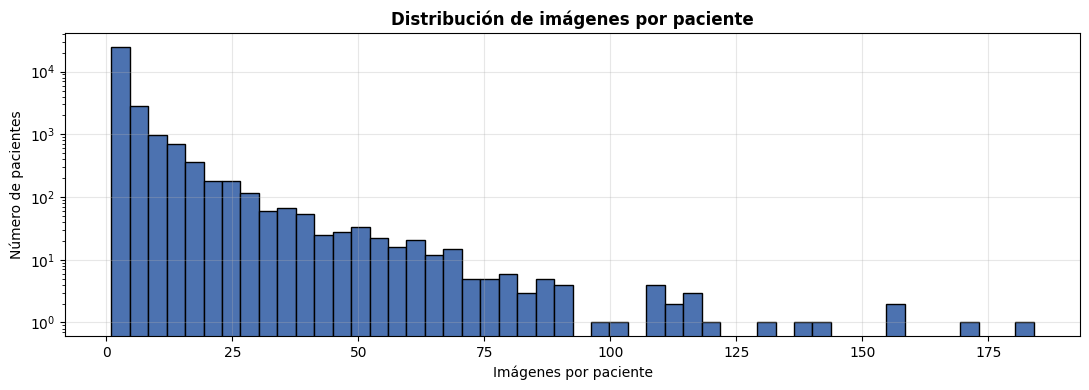

In [14]:
imgs_por_paciente = df.groupby("Patient ID").size()
print(f"Pacientes únicos: {len(imgs_por_paciente)}")
print(f"Imágenes totales: {len(df)}")
print(f"Imágenes por paciente: "
      f"min={imgs_por_paciente.min()}, "
      f"median={imgs_por_paciente.median():.0f}, "
      f"mean={imgs_por_paciente.mean():.1f}, "
      f"max={imgs_por_paciente.max()}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(imgs_por_paciente.values, bins=50, color=PALETA["azul"],
        edgecolor="black")
ax.set_xlabel("Imágenes por paciente")
ax.set_ylabel("Número de pacientes")
ax.set_title("Distribución de imágenes por paciente", fontweight="bold")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS_DIR / "04_imgs_por_paciente.png", dpi=120, bbox_inches="tight")
plt.show()

## **Sección 4.1 · View Position (PA vs AP)**

PA (postero-anterior) es la vista de pie, de calidad alta. AP
(antero-posterior) es de cama y suele usarse en pacientes de UCI, con
mayor carga patológica y peor calidad. Si el modelo aprende "AP ⇒
enfermo", está explotando un shortcut técnico que no generaliza a otro
hospital con distinto reparto PA/AP.

In [15]:
vp_counts = df["View Position"].value_counts()
print("Distribución View Position:")
print(vp_counts)
print()
print("Prevalencia 'con patología' por vista:")
for vp in vp_counts.index:
    sub = df[df["View Position"] == vp]
    pct = 100 * (sub["n_patologias"] > 0).mean()
    print(f"  {vp}: {pct:.2f}%  "
          f"({int((sub['n_patologias'] > 0).sum()):,} / {len(sub):,})")

Distribución View Position:
View Position
PA    67310
AP    44810
Name: count, dtype: int64

Prevalencia 'con patología' por vista:
  PA: 41.61%  (28,008 / 67,310)
  AP: 53.00%  (23,751 / 44,810)


In [16]:
filas_vp = []
for pat in PATOLOGIAS_14:
    for vp in vp_counts.index:
        sub = df[df["View Position"] == vp]
        filas_vp.append({
            "clase": pat,
            "vista": vp,
            "pct_positivos": 100 * sub[pat].mean(),
            "n_positivos": int(sub[pat].sum()),
        })
df_vp_pivot = (
    pd.DataFrame(filas_vp)
    .pivot(index="clase", columns="vista", values="pct_positivos")
)
df_vp_pivot["ratio_AP/PA"] = df_vp_pivot["AP"] / df_vp_pivot["PA"].replace(0, np.nan)
df_vp_pivot = df_vp_pivot.sort_values("ratio_AP/PA", ascending=False)
df_vp_pivot.round(2)

vista,AP,PA,ratio_AP/PA
clase,,,
Edema,4.52,0.41,11.03
Consolidation,7.02,2.26,3.11
Pneumonia,1.79,0.94,1.91
Infiltration,23.52,13.90,1.69
Effusion,15.01,9.79,1.53
Atelectasis,13.01,8.51,1.53
Cardiomegaly,2.71,2.32,1.17
Emphysema,2.27,2.23,1.02
Mass,4.94,5.30,0.93


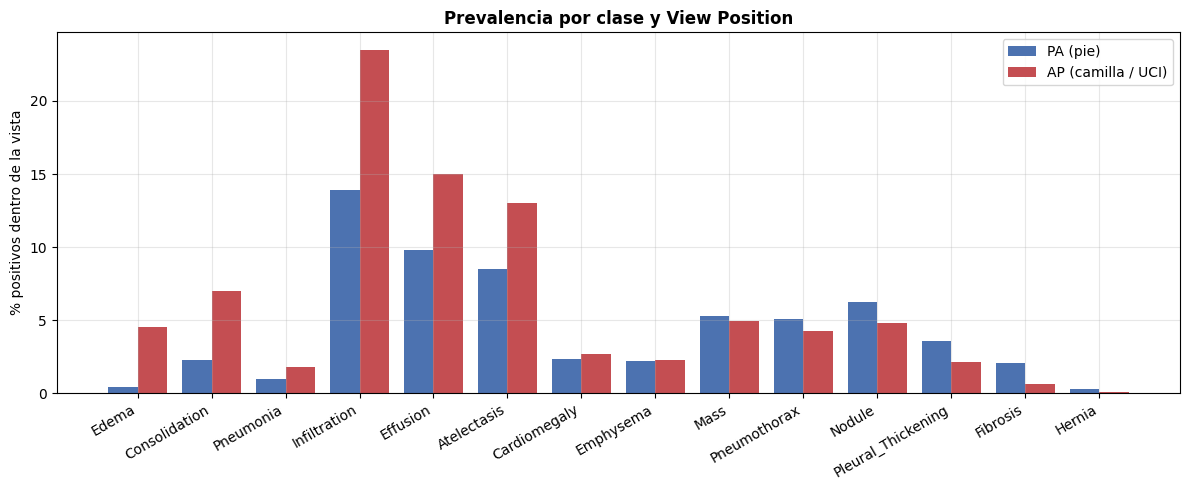

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
orden = df_vp_pivot.index.tolist()
x = np.arange(len(orden))
w = 0.4
ax.bar(x - w / 2, df_vp_pivot["PA"], w, label="PA (pie)", color=PALETA["azul"])
ax.bar(x + w / 2, df_vp_pivot["AP"], w, label="AP (camilla / UCI)",
       color=PALETA["rojo"])
ax.set_xticks(x)
ax.set_xticklabels(orden, rotation=30, ha="right")
ax.set_ylabel("% positivos dentro de la vista")
ax.set_title("Prevalencia por clase y View Position", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS_DIR / "10_pa_vs_ap.png", dpi=120, bbox_inches="tight")
plt.show()

### **Distribución de Patient Age**

Antes de cortar por buckets revisamos la distribución continua y posibles
outliers. El CSV de NIH ha reportado edades inválidas (valores negativos,
110 años) que llegan del NLP mining original. Cuantificamos la magnitud
del ruido y los percentiles p1/p5/p95/p99 para decidir si el bucket `80+`
queda dominado por registros no clínicos.

In [18]:
age_raw = df["Patient Age"]
if age_raw.dtype == "object":
    age_serie = pd.to_numeric(
        age_raw.astype(str).str.extract(r"(\d+)", expand=False),
        errors="coerce",
    )
else:
    age_serie = pd.to_numeric(age_raw, errors="coerce")

LIM_INF, LIM_SUP = 0, 110
edad_total = len(age_serie)
edad_nan = int(age_serie.isna().sum())
edad_fuera_rango = int(((age_serie < LIM_INF) | (age_serie > LIM_SUP)).sum())
edad_sup_100 = int((age_serie > 100).sum())
edad_neg = int((age_serie < 0).sum())

print(f"Registros con edad: {edad_total - edad_nan:,} / {edad_total:,}")
print(f"  Faltantes (NaN):     {edad_nan:,}")
print(f"  Fuera de [0, 110]:   {edad_fuera_rango:,}")
print(f"    - edad > 100:      {edad_sup_100:,}")
print(f"    - edad < 0:        {edad_neg:,}")
print()
print("Percentiles de edad (sin NaN):")
for q in [0.01, 0.05, 0.5, 0.95, 0.99, 1.0]:
    print(f"  p{int(q * 100):>3} = {age_serie.quantile(q):.1f}")

Registros con edad: 112,120 / 112,120
  Faltantes (NaN):     0
  Fuera de [0, 110]:   16
    - edad > 100:      16
    - edad < 0:        0

Percentiles de edad (sin NaN):
  p  1 = 9.0
  p  5 = 18.0
  p 50 = 49.0
  p 95 = 72.0
  p 99 = 80.0
  p100 = 414.0


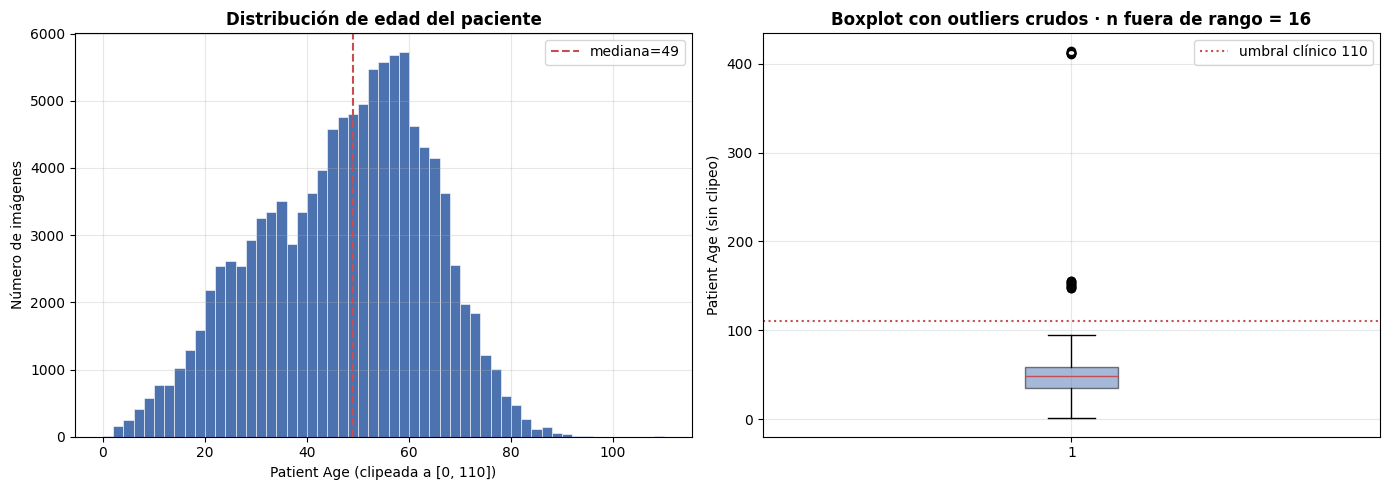

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

edad_valida = age_serie.clip(lower=LIM_INF, upper=LIM_SUP).dropna()
axes[0].hist(edad_valida, bins=np.arange(0, 111, 2), color=PALETA["azul"],
             edgecolor="white", linewidth=0.4)
axes[0].axvline(edad_valida.median(), color=PALETA["rojo"], linestyle="--",
                label=f"mediana={edad_valida.median():.0f}")
axes[0].set_xlabel("Patient Age (clipeada a [0, 110])")
axes[0].set_ylabel("Número de imágenes")
axes[0].set_title("Distribución de edad del paciente", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(age_serie.dropna(), vert=True, showfliers=True,
                patch_artist=True,
                boxprops={"facecolor": PALETA["azul"], "alpha": 0.5},
                medianprops={"color": PALETA["rojo"]})
axes[1].axhline(LIM_SUP, color=PALETA["rojo"], linestyle=":",
                label=f"umbral clínico {LIM_SUP}")
axes[1].set_ylabel("Patient Age (sin clipeo)")
axes[1].set_title(
    f"Boxplot con outliers crudos · n fuera de rango = {edad_fuera_rango}",
    fontweight="bold"
)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_DIR / "10b_age_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

## **Sección 4.2 · Prevalencia por grupo de edad por clase**

Patologías asociadas a edad avanzada (Mass, Nodule, Cardiomegaly) deberían
concentrarse en 60+. Pneumothorax suele ser bimodal (jóvenes + ancianos).
Si una clase no tiene patrón por edad, no hay señal de confusión demográfica
y el sampler no necesita estratificar por edad.

In [20]:
df["age_bucket_global"] = pd.cut(
    df["Patient Age"],
    bins=[-1, 20, 40, 60, 80, 200],
    labels=["<20", "20-40", "40-60", "60-80", "80+"],
)
print("Distribución por grupo de edad:")
print(df["age_bucket_global"].value_counts().sort_index())

Distribución por grupo de edad:
age_bucket_global
<20       7812
20-40    30143
40-60    49502
60-80    23766
80+        891
Name: count, dtype: int64


In [21]:
filas_edad = []
for pat in PATOLOGIAS_14:
    for b in df["age_bucket_global"].cat.categories:
        sub = df[df["age_bucket_global"] == b]
        filas_edad.append({
            "clase": pat,
            "edad": str(b),
            "pct_positivos": 100 * sub[pat].mean() if len(sub) > 0 else 0.0,
        })
df_edad = (
    pd.DataFrame(filas_edad)
    .pivot(index="clase", columns="edad", values="pct_positivos")
)
df_edad = df_edad[["<20", "20-40", "40-60", "60-80", "80+"]]
df_edad.round(2)

edad,<20,20-40,40-60,60-80,80+
clase,,,,,
Atelectasis,6.58,7.60,11.27,12.86,13.24
Cardiomegaly,2.46,2.55,2.36,2.55,4.38
Consolidation,4.85,4.12,4.06,4.17,5.39
Edema,2.02,2.35,2.10,1.63,0.90
Effusion,8.14,10.07,12.29,14.40,15.49
Emphysema,2.32,1.70,2.01,3.36,3.59
Fibrosis,0.54,0.99,1.62,2.14,3.93
Hernia,0.01,0.02,0.19,0.40,3.48
Infiltration,19.61,18.48,17.14,17.42,18.97


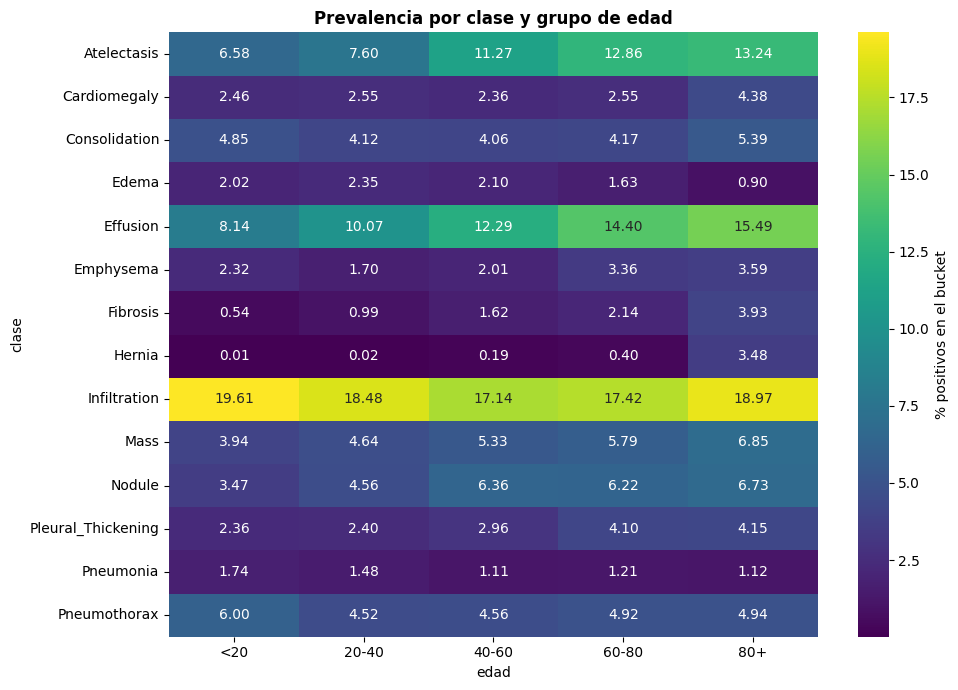

In [22]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df_edad, annot=True, fmt=".2f", cmap="viridis", ax=ax,
            cbar_kws={"label": "% positivos en el bucket"})
ax.set_title("Prevalencia por clase y grupo de edad", fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS_DIR / "11_prevalencia_edad.png", dpi=120, bbox_inches="tight")
plt.show()

## **Sección 4.3 · Prevalencia por género**

Proporción global M/F del dataset y prevalencia de cada clase por género.
Si `ratio_M/F` se desvía mucho de la base (~1,2), el Fisher sampler podría
beneficiarse de estratificar también por género, no solo por clase.

In [23]:
gen_counts = df["Patient Gender"].value_counts()
ratio_base = gen_counts.get("M", 0) / max(gen_counts.get("F", 1), 1)
print(f"Global M:{gen_counts.get('M', 0):,}  F:{gen_counts.get('F', 0):,}  "
      f"ratio_base_M/F={ratio_base:.3f}")

filas_gen = []
for pat in PATOLOGIAS_14:
    for g in ["M", "F"]:
        sub = df[df["Patient Gender"] == g]
        filas_gen.append({
            "clase": pat,
            "genero": g,
            "pct_positivos": 100 * sub[pat].mean(),
            "n_positivos": int(sub[pat].sum()),
        })
df_gen = (
    pd.DataFrame(filas_gen)
    .pivot(index="clase", columns="genero", values="pct_positivos")
)
df_gen["ratio_M/F"] = df_gen["M"] / df_gen["F"].replace(0, np.nan)
df_gen["desvio_vs_base"] = df_gen["ratio_M/F"] / ratio_base
df_gen = df_gen.sort_values("ratio_M/F", ascending=False)
df_gen.round(3)

Global M:63,340  F:48,780  ratio_base_M/F=1.298


genero,F,M,ratio_M/F,desvio_vs_base
clase,,,,
Emphysema,1.857,2.542,1.369,1.054
Mass,4.619,5.572,1.206,0.929
Pleural_Thickening,2.753,3.224,1.171,0.902
Atelectasis,9.539,10.903,1.143,0.880
Pneumonia,1.216,1.323,1.088,0.838
Nodule,5.424,5.818,1.073,0.826
Infiltration,17.358,18.041,1.039,0.800
Consolidation,4.102,4.209,1.026,0.790
Effusion,12.058,11.738,0.973,0.750


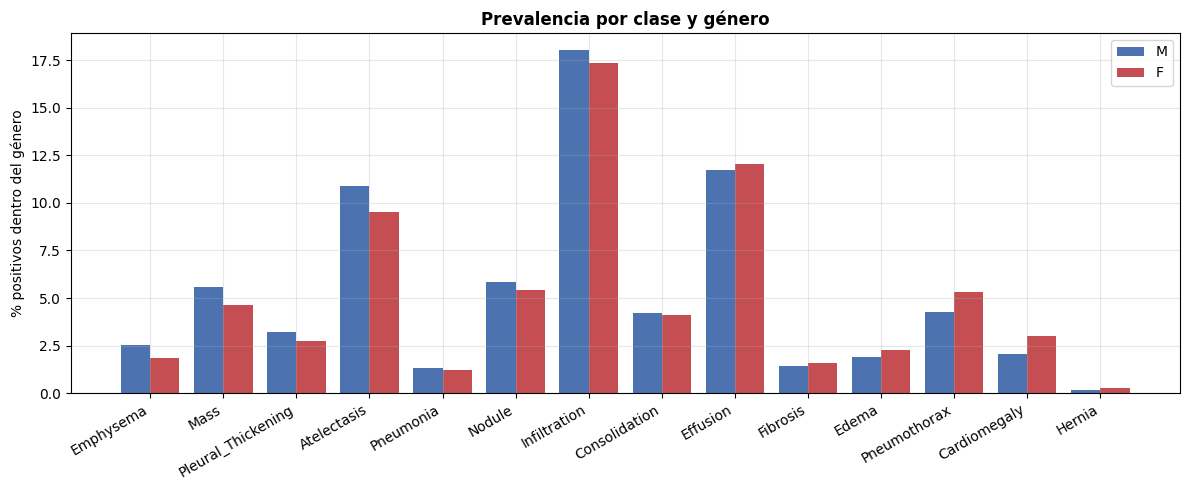

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
orden_gen = df_gen.index.tolist()
x = np.arange(len(orden_gen))
w = 0.4
ax.bar(x - w / 2, df_gen["M"], w, label="M", color=PALETA["azul"])
ax.bar(x + w / 2, df_gen["F"], w, label="F", color=PALETA["rojo"])
ax.set_xticks(x)
ax.set_xticklabels(orden_gen, rotation=30, ha="right")
ax.set_ylabel("% positivos dentro del género")
ax.set_title("Prevalencia por clase y género", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS_DIR / "12_prevalencia_genero.png", dpi=120, bbox_inches="tight")
plt.show()

## **Sección 4.4 · Follow-up # y complejidad clínica**

`Follow-up #` indica el orden del estudio dentro del historial del paciente.
Algunos pacientes crónicos acumulan 100+ estudios. Si caen todos en train,
la distribución empírica del loss queda dominada por ese patrón. Buscamos:
1. Distribución del max follow-up por paciente.
2. Correlación max_followup vs promedio de patologías por estudio.
3. Top 10 pacientes más "complejos".

In [25]:
patient_stats = (
    df.groupby("Patient ID")
    .agg(
        max_followup=("Follow-up #", "max"),
        total_imgs=("Image Index", "count"),
        avg_n_pat=("n_patologias", "mean"),
        any_pat=("n_patologias", lambda s: int((s > 0).any())),
    )
    .reset_index()
)

print(f"Pacientes únicos: {len(patient_stats):,}")
print(
    "Max follow-up por paciente: "
    f"min={patient_stats['max_followup'].min()}, "
    f"median={patient_stats['max_followup'].median():.0f}, "
    f"p95={patient_stats['max_followup'].quantile(0.95):.0f}, "
    f"max={patient_stats['max_followup'].max()}"
)
print()

corr = patient_stats[["max_followup", "total_imgs", "avg_n_pat"]].corr()
print("Correlación entre métricas paciente:")
print(corr.round(3))
print()

print("Top 10 pacientes por max follow-up:")
top10 = patient_stats.nlargest(10, "max_followup").reset_index(drop=True)
print(top10.to_string(index=False))

Pacientes únicos: 30,805
Max follow-up por paciente: min=0, median=0, p95=13, max=183

Correlación entre métricas paciente:
              max_followup  total_imgs  avg_n_pat
max_followup         1.000       1.000      0.203
total_imgs           1.000       1.000      0.203
avg_n_pat            0.203       0.203      1.000

Top 10 pacientes por max follow-up:
 Patient ID  max_followup  total_imgs  avg_n_pat  any_pat
      10007           183         184   1.380435        1
      13670           172         173   1.104046        1
      15530           157         158   1.082278        1
      12834           156         157   1.452229        1
      13993           142         143   1.552448        1
       1836           136         137   1.087591        1
      19124           129         130   1.300000        1
      20213           118         119   1.596639        1
      17138           116         117   1.188034        1
      11237           115         116   1.086207        1


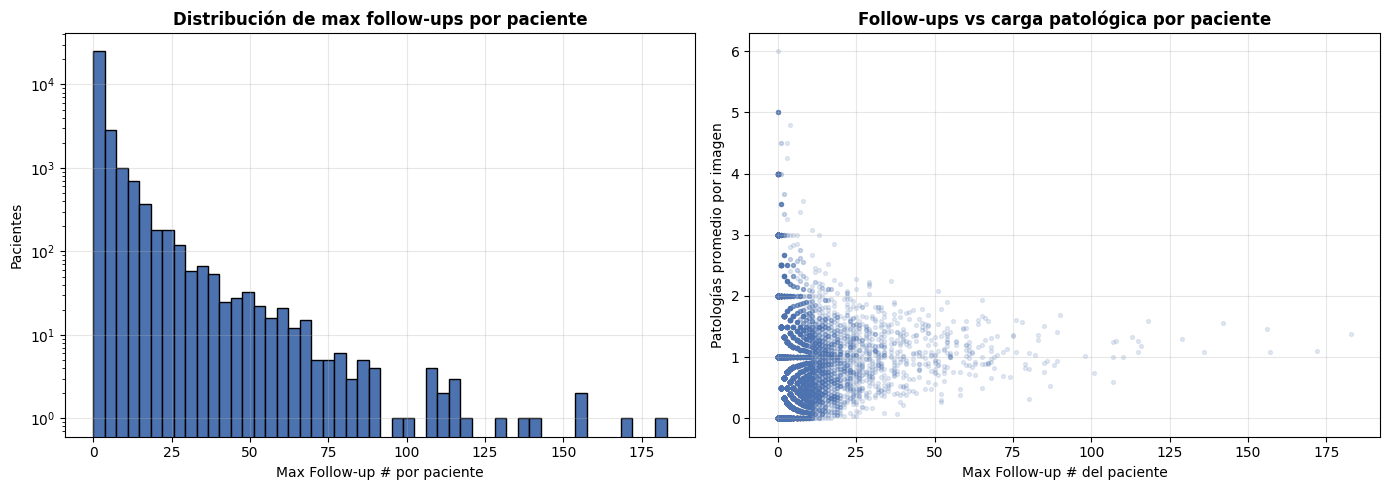

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(
    patient_stats["max_followup"].values, bins=50,
    color=PALETA["azul"], edgecolor="black"
)
axes[0].set_xlabel("Max Follow-up # por paciente")
axes[0].set_ylabel("Pacientes")
axes[0].set_yscale("log")
axes[0].set_title("Distribución de max follow-ups por paciente",
                  fontweight="bold")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(
    patient_stats["max_followup"],
    patient_stats["avg_n_pat"],
    alpha=0.15, s=8, color=PALETA["azul"]
)
axes[1].set_xlabel("Max Follow-up # del paciente")
axes[1].set_ylabel("Patologías promedio por imagen")
axes[1].set_title("Follow-ups vs carga patológica por paciente",
                  fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_DIR / "13_followups.png", dpi=120, bbox_inches="tight")
plt.show()

## **Sección 4.5 · Resolución original y pixel spacing**

NIH CXR14 se distribuye como PNG 1024×1024, pero el CSV conserva la
resolución original del scanner. Las imágenes fuera del canon delatan
origen distinto (scanner, hospital, fabricante) y son fuente candidata
de domain shift si caen de forma desbalanceada en val/test.

In [27]:
print("Width  original:", df["OriginalImage_Width"].describe().round(1).to_dict())
print()
print("Height original:", df["OriginalImage_Height"].describe().round(1).to_dict())
print()

df["aspect_ratio"] = df["OriginalImage_Width"] / df["OriginalImage_Height"]
print("Aspect ratio:", df["aspect_ratio"].describe().round(3).to_dict())
print()

not_std = df[
    (df["OriginalImage_Width"] != 1024) | (df["OriginalImage_Height"] != 1024)
]
print(f"Imágenes NO 1024x1024: {len(not_std):,} "
      f"({100 * len(not_std) / len(df):.2f} %)")
print()

Width  original: {'count': 112120.0, 'mean': 2646.1, 'std': 341.2, 'min': 1143.0, '25%': 2500.0, '50%': 2518.0, '75%': 2992.0, 'max': 3827.0}

Height original: {'count': 112120.0, 'mean': 2486.4, 'std': 401.3, 'min': 966.0, '25%': 2048.0, '50%': 2544.0, '75%': 2991.0, 'max': 4715.0}

Aspect ratio: {'count': 112120.0, 'mean': 1.079, 'std': 0.145, 'min': 0.542, '25%': 1.0, '50%': 1.074, '75%': 1.221, 'max': 1.793}

Imágenes NO 1024x1024: 112,120 (100.00 %)



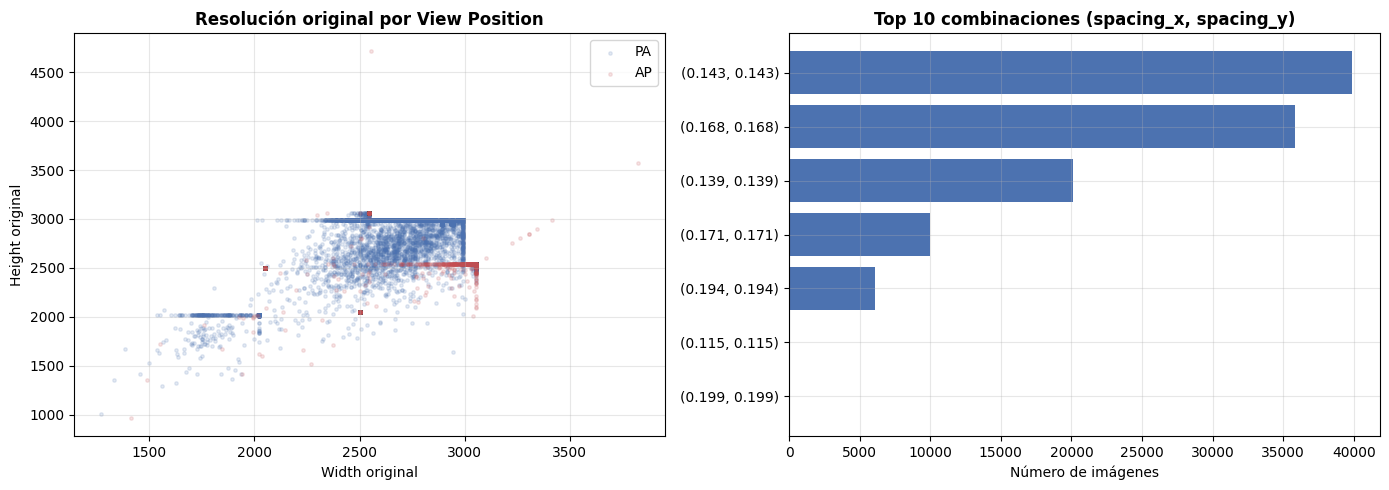

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter resolución coloreado por View Position (solo muestra para legibilidad)
colores_vp = {"PA": PALETA["azul"], "AP": PALETA["rojo"]}
for vp, color in colores_vp.items():
    sub = df[df["View Position"] == vp]
    if len(sub) > 15000:
        sub = sub.sample(15000, random_state=SEED)
    axes[0].scatter(
        sub["OriginalImage_Width"], sub["OriginalImage_Height"],
        alpha=0.15, s=6, color=color, label=vp
    )
axes[0].set_xlabel("Width original")
axes[0].set_ylabel("Height original")
axes[0].set_title("Resolución original por View Position",
                  fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Top 10 combinaciones pixel spacing
sp_combos = (
    df.groupby(["PixelSpacing_x", "PixelSpacing_y"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)
axes[1].barh(
    [f"({x:.3f}, {y:.3f})" for (x, y) in sp_combos.index],
    sp_combos.values, color=PALETA["azul"]
)
axes[1].set_xlabel("Número de imágenes")
axes[1].set_title("Top 10 combinaciones (spacing_x, spacing_y)",
                  fontweight="bold")
axes[1].grid(True, alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGS_DIR / "14_resolucion_spacing.png", dpi=120, bbox_inches="tight")
plt.show()

### **Top combinaciones (Width, Height) originales**

Mismo ejercicio que con pixel spacing: agrupamos imágenes por par
(OriginalImage_Width, OriginalImage_Height) crudo del CSV para ver si
existen cohortes dominantes de scanner antes del resize a 1024 que aplica
la distribución pública de NIH. Se reporta cobertura acumulada del top-N
para entender qué fracción del dataset proviene de una resolución atípica.

In [29]:
wh_combos = (
    df.groupby(["OriginalImage_Width", "OriginalImage_Height"])
    .size()
    .sort_values(ascending=False)
    .reset_index(name="n_imgs")
)
wh_combos["pct"] = 100 * wh_combos["n_imgs"] / len(df)
wh_combos["pct_acum"] = wh_combos["pct"].cumsum()

total_combos_wh = len(wh_combos)
print(f"Combinaciones únicas (Width, Height): {total_combos_wh:,}")
print("\nTop 15:")
print(wh_combos.head(15).to_string(index=False,
                                    formatters={"pct": "{:.2f}".format,
                                                "pct_acum": "{:.2f}".format}))
for topn in [1, 3, 5, 10, 20]:
    acum = wh_combos.head(topn)["pct"].sum()
    print(f"  Top {topn:>2}: {acum:.2f} % del dataset")

Combinaciones únicas (Width, Height): 10,471

Top 15:
 OriginalImage_Width  OriginalImage_Height  n_imgs   pct pct_acum
                2500                  2048   37153 33.14    33.14
                2992                  2991   21961 19.59    52.72
                3056                  2544   15340 13.68    66.41
                2048                  2500    8683  7.74    74.15
                2021                  2021    4411  3.93    78.08
                2544                  3056    2418  2.16    80.24
                2990                  2991     483  0.43    80.67
                2020                  2021     331  0.30    80.97
                2021                  2020     279  0.25    81.22
                2986                  2991     166  0.15    81.36
                2992                  2989     140  0.12    81.49
                2674                  2991      93  0.08    81.57
                2982                  2991      90  0.08    81.65
                2742  

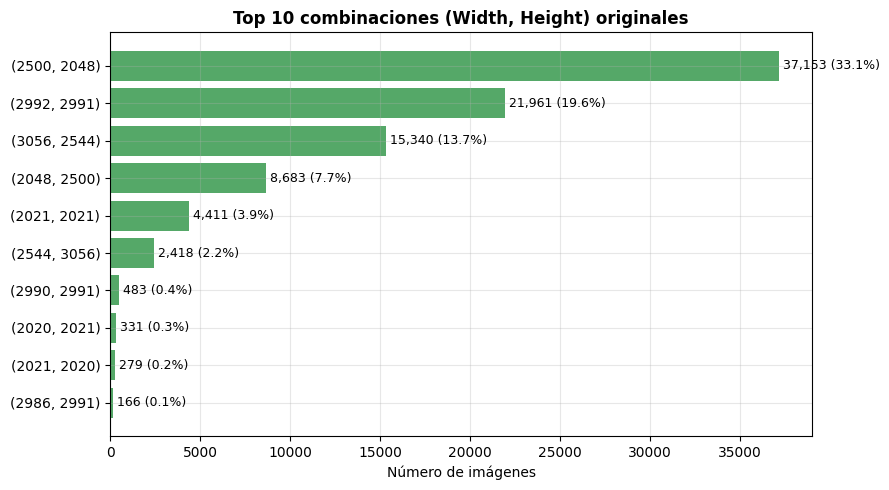

In [30]:
top10_wh = wh_combos.head(10)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    [f"({int(w)}, {int(h)})" for w, h in zip(top10_wh["OriginalImage_Width"],
                                             top10_wh["OriginalImage_Height"])],
    top10_wh["n_imgs"], color=PALETA["verde"]
)
for i, (n, pct) in enumerate(zip(top10_wh["n_imgs"], top10_wh["pct"])):
    ax.text(n, i, f" {n:,} ({pct:.1f}%)", va="center", fontsize=9)
ax.set_xlabel("Número de imágenes")
ax.set_title("Top 10 combinaciones (Width, Height) originales",
             fontweight="bold")
ax.grid(True, alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGS_DIR / "14b_top_combinations_wh.png", dpi=120, bbox_inches="tight")
plt.show()

## **Sección 4.6 · Top combinaciones Finding Labels**

`Finding Labels` tiene 836 combinaciones únicas. Top 30 concentran la
mayoría del peso. Sirve para complementar la co-ocurrencia condicional
de la Sección 3 con una vista "qué patrones comorbidos son efectivamente
frecuentes en el dataset" (útil para diseñar heads dedicadas a
comorbilidades específicas).

In [31]:
combo_counts = df["Finding Labels"].value_counts()
print(f"Combinaciones únicas de Finding Labels: {len(combo_counts):,}")
print()
print("Top 30 combinaciones:")
print(combo_counts.head(30))

# Longitud de la combinación (nº de patologías encoded)
df["n_componentes_label"] = df["Finding Labels"].str.count(r"\|") + 1
df.loc[df["Finding Labels"] == "No Finding", "n_componentes_label"] = 0
print("\nNº de patologías por imagen (según string Finding Labels):")
print(df["n_componentes_label"].value_counts().sort_index())

Combinaciones únicas de Finding Labels: 836

Top 30 combinaciones:
Finding Labels
No Finding                           60361
Infiltration                          9547
Atelectasis                           4215
Effusion                              3955
Nodule                                2705
Pneumothorax                          2194
Mass                                  2139
Effusion|Infiltration                 1603
Atelectasis|Infiltration              1350
Consolidation                         1310
Atelectasis|Effusion                  1165
Pleural_Thickening                    1126
Cardiomegaly                          1093
Emphysema                              892
Infiltration|Nodule                    829
Atelectasis|Effusion|Infiltration      737
Fibrosis                               727
Edema                                  628
Cardiomegaly|Effusion                  484
Consolidation|Infiltration             441
Infiltration|Mass                      420
Effusion|Pneumo

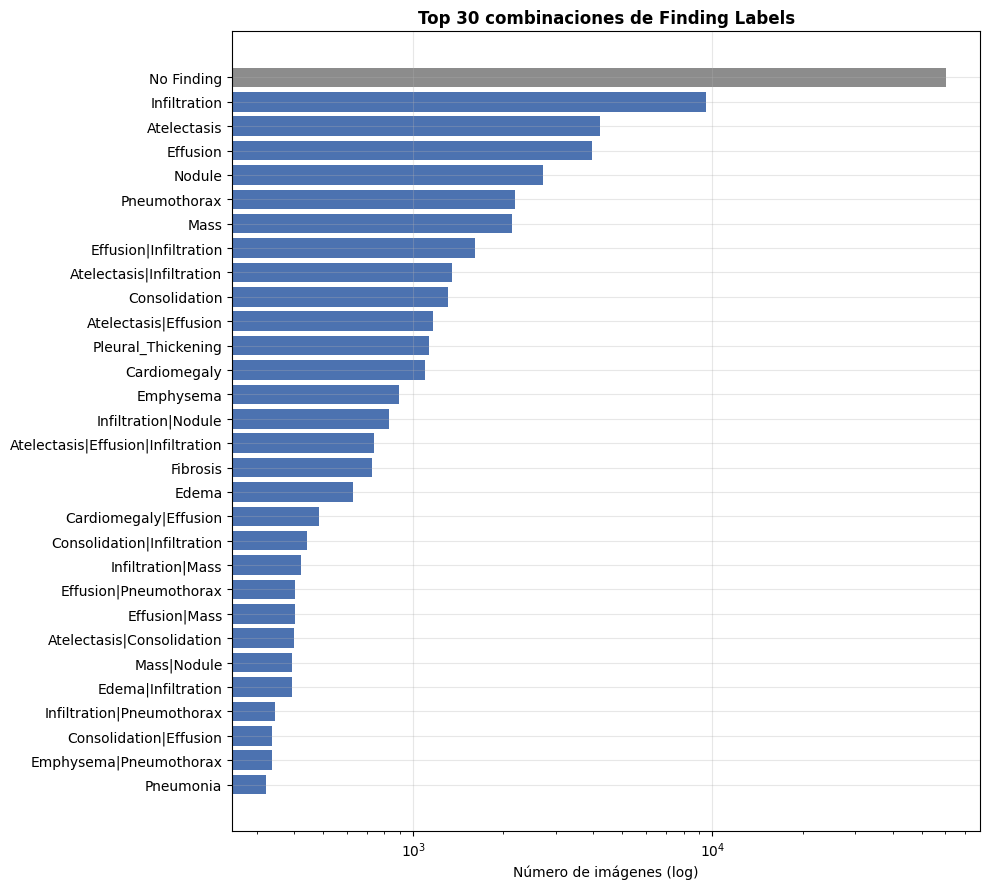

In [32]:
fig, ax = plt.subplots(figsize=(10, 9))
top30 = combo_counts.head(30)
colores_combo = [
    PALETA["gris"] if c == "No Finding" else PALETA["azul"]
    for c in top30.index
]
ax.barh(top30.index, top30.values, color=colores_combo)
ax.set_xlabel("Número de imágenes (log)")
ax.set_xscale("log")
ax.set_title("Top 30 combinaciones de Finding Labels", fontweight="bold")
ax.grid(True, alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGS_DIR / "15_top_combinaciones.png", dpi=120, bbox_inches="tight")
plt.show()

## **Sección 5. Auditoría del split actual (3-fold CV)**

El pipeline exp1v20 usa `MultilabelStratifiedKFold` con `N_FOLDS=3`,
`RUN_FOLDS=1`. Reproducimos ese split con el subset de 6 clases + subsample
No Finding al 30% para auditarlo y medir leakage paciente.

In [33]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

SEED_V20 = 42
NF_FRAC_V20 = 0.30
NF_SEED_V20 = 444
PATOLOGIAS_V20 = [
    "Infiltration",
    "Effusion",
    "Atelectasis",
    "Nodule",
    "Mass",
    "Pneumothorax",
]

df_nf_sub = df[df["No_Finding"] == 1].sample(
    frac=NF_FRAC_V20, random_state=NF_SEED_V20
)
df_non_nf = df[df["No_Finding"] == 0]
df_v20 = pd.concat([df_non_nf, df_nf_sub], ignore_index=True)
print(f"Subset reconstruido (v20): {len(df_v20)} imágenes")

patient_df_v20 = df_v20.groupby("Patient ID")[PATOLOGIAS_V20].max().reset_index()
patient_labels_v20 = patient_df_v20[PATOLOGIAS_V20].values

mskf = MultilabelStratifiedKFold(n_splits=3, shuffle=True, random_state=SEED_V20)
fold_map = {}
for fi, (_, vp) in enumerate(mskf.split(patient_df_v20, patient_labels_v20)):
    for pid in patient_df_v20.iloc[vp]["Patient ID"]:
        fold_map[pid] = fi
df_v20["fold"] = df_v20["Patient ID"].map(fold_map)

print("\nReparto por fold:")
for fi in range(3):
    n = int((df_v20["fold"] == fi).sum())
    pac = df_v20[df_v20["fold"] == fi]["Patient ID"].nunique()
    print(f"  Fold {fi}: {n:>6d} imgs, {pac:>5d} pacientes "
          f"({100 * n / len(df_v20):.1f}%)")

# Verificar leakage paciente entre folds (debe ser 0 en todos los pares)
print("\nLeakage paciente entre folds:")
pacientes_por_fold = {
    fi: set(df_v20[df_v20["fold"] == fi]["Patient ID"]) for fi in range(3)
}
for a, b in combinations(range(3), 2):
    inter = pacientes_por_fold[a] & pacientes_por_fold[b]
    print(f"  Fold {a} ∩ Fold {b}: {len(inter)} pacientes "
          f"(esperado 0)")

Subset reconstruido (v20): 69867 imágenes

Reparto por fold:
  Fold 0:  23704 imgs,  6829 pacientes (33.9%)
  Fold 1:  22982 imgs,  6830 pacientes (32.9%)
  Fold 2:  23181 imgs,  6830 pacientes (33.2%)

Leakage paciente entre folds:
  Fold 0 ∩ Fold 1: 0 pacientes (esperado 0)
  Fold 0 ∩ Fold 2: 0 pacientes (esperado 0)
  Fold 1 ∩ Fold 2: 0 pacientes (esperado 0)


## **Sección 6. Propuesta de split 70/15/15 patient-level**

Migramos a `MultilabelStratifiedShuffleSplit` con tres particiones
independientes, agrupando por `Patient ID` para evitar leakage y
estratificando sobre las 14 patologías con semilla fija `SEED=67`.

In [34]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit


def split_70_15_15(df_full, cols_estratificar, seed=SEED):
    """Dos rupturas secuenciales sobre el agregado paciente:
    1) 70% train / 30% temp
    2) 50% val / 50% test del temp (= 15% / 15% total)
    """
    patient_agg = df_full.groupby("Patient ID")[cols_estratificar].max().reset_index()
    labels_agg = patient_agg[cols_estratificar].values

    mss1 = MultilabelStratifiedShuffleSplit(
        n_splits=1, test_size=0.30, random_state=seed
    )
    idx_train, idx_temp = next(mss1.split(patient_agg, labels_agg))
    temp_df = patient_agg.iloc[idx_temp].reset_index(drop=True)
    temp_labels = temp_df[cols_estratificar].values

    mss2 = MultilabelStratifiedShuffleSplit(
        n_splits=1, test_size=0.50, random_state=seed
    )
    idx_val, idx_test = next(mss2.split(temp_df, temp_labels))

    pids_train = set(patient_agg.iloc[idx_train]["Patient ID"])
    pids_val = set(temp_df.iloc[idx_val]["Patient ID"])
    pids_test = set(temp_df.iloc[idx_test]["Patient ID"])

    out = df_full.copy()
    out["split"] = "unknown"
    out.loc[out["Patient ID"].isin(pids_train), "split"] = "train"
    out.loc[out["Patient ID"].isin(pids_val), "split"] = "val"
    out.loc[out["Patient ID"].isin(pids_test), "split"] = "test"
    return out


df_split = split_70_15_15(df, PATOLOGIAS_14, seed=SEED)

print("Reparto 70/15/15 sobre el dataset completo:")
for sp in ["train", "val", "test"]:
    sub = df_split[df_split["split"] == sp]
    pct = 100 * len(sub) / len(df_split)
    print(f"  {sp:<5s}: {len(sub):>6d} imgs, "
          f"{sub['Patient ID'].nunique():>5d} pacientes ({pct:.2f}%)")

print("\nLeakage paciente entre particiones:")
splits_pac = {
    sp: set(df_split[df_split["split"] == sp]["Patient ID"])
    for sp in ["train", "val", "test"]
}
for a, b in combinations(["train", "val", "test"], 2):
    inter = splits_pac[a] & splits_pac[b]
    print(f"  {a} ∩ {b}: {len(inter)} (esperado 0)")

Reparto 70/15/15 sobre el dataset completo:
  train:  78024 imgs, 21563 pacientes (69.59%)
  val  :  16845 imgs,  4621 pacientes (15.02%)
  test :  17251 imgs,  4621 pacientes (15.39%)

Leakage paciente entre particiones:
  train ∩ val: 0 (esperado 0)
  train ∩ test: 0 (esperado 0)
  val ∩ test: 0 (esperado 0)


### **Preservación de proporciones por clase**

La estratificación multilabel debe mantener el porcentaje de positivos por
clase aproximadamente constante en las tres particiones.

In [35]:
filas_prop = []
for sp in ["train", "val", "test"]:
    sub = df_split[df_split["split"] == sp]
    for pat in PATOLOGIAS_14:
        filas_prop.append(
            {"split": sp, "clase": pat, "%positivos": 100 * sub[pat].mean()}
        )
df_prop = (
    pd.DataFrame(filas_prop)
    .pivot(index="clase", columns="split", values="%positivos")
    .rename_axis(None, axis=1)
)
df_prop["%_total"] = 100 * df[PATOLOGIAS_14].mean()
df_prop = df_prop[["train", "val", "test", "%_total"]].round(2)
df_prop

,train,val,test,%_total
clase,,,,
Atelectasis,10.32,10.26,10.32,10.31
Cardiomegaly,2.52,2.52,2.21,2.48
Consolidation,4.11,4.36,4.23,4.16
Edema,1.99,2.10,2.28,2.05
Effusion,11.68,11.87,12.76,11.88
Emphysema,2.26,1.93,2.48,2.24
Fibrosis,1.52,1.42,1.50,1.50
Hernia,0.20,0.26,0.16,0.20
Infiltration,17.65,17.80,18.10,17.74


## **Sección 7. Análisis de predicciones del checkpoint exp1v20**

Cargamos el checkpoint descargado desde HF Hub y evaluamos sobre el fold 0
(validación del 3-fold CV original) para obtener métricas por clase,
distribución de logits y thresholds óptimos.

In [49]:
import timm
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

CKPT_PATH = "/workspace/ckpts/exp1v20/ckpt_exp1v20_f0_best.pt"
THR_PATH = "/workspace/ckpts/exp1v20/exp1v20_f0_thresholds.json"

print(f"Checkpoint existe: {os.path.exists(CKPT_PATH)}")
print(f"Thresholds existen: {os.path.exists(THR_PATH)}")

Checkpoint existe: True
Thresholds existen: True


### **Definición del modelo y carga del checkpoint**

In [50]:
MODEL_NAME = "convnext_base.fb_in22k_ft_in1k_384"
NUM_CLASSES_V20 = 6


class LSEPool2d(torch.nn.Module):
    """Log-Sum-Exp Pooling (Wang et al. CVPR 2017, r=10 empírico CXR14).
    Réplica exacta de scripts/exp1_v20/train_exp1v20.py:509-521.
    """

    def __init__(self, r=10.0):
        super().__init__()
        self.r = r

    def forward(self, x):
        b, c, h, w = x.shape
        x_flat = x.view(b, c, -1)
        x_max = x_flat.max(dim=2, keepdim=True).values
        exp_sum = torch.exp(self.r * (x_flat - x_max)).mean(dim=2, keepdim=True)
        out = x_max + (1.0 / self.r) * torch.log(exp_sum + 1e-8)
        return out.view(b, c, 1, 1)


class CXRExpertSingleHead(torch.nn.Module):
    """Réplica exacta del modelo de scripts/exp1_v20/train_exp1v20.py:524-566.
    Clave: features_only=True + LSEPool2d + head=Sequential(Dropout, Linear).
    Si se usa otro contrato (num_classes=0 + GAP implícito + Linear) el
    state_dict del checkpoint v20 no mapea y el modelo queda aleatorio
    (iter3: 344 missing, 6 unexpected → F1 macro 0,25 vs real 0,48).
    """

    def __init__(self, model_name, num_classes=6, drop_path=0.2):
        super().__init__()
        _tmp = timm.create_model(model_name, pretrained=False, features_only=True)
        last_idx = len(_tmp.feature_info) - 1
        del _tmp
        self.backbone = timm.create_model(
            model_name,
            pretrained=False,
            features_only=True,
            out_indices=(last_idx,),
            drop_path_rate=drop_path,
        )
        feat_dim = self.backbone.feature_info[-1]["num_chs"]

        self.pool = LSEPool2d(r=10.0)
        self.head = torch.nn.Sequential(
            torch.nn.Dropout(0.3),
            torch.nn.Linear(feat_dim, num_classes),
        )
        self.feat_dim = feat_dim

    def forward(self, x):
        feat = self.backbone(x)[0]
        feat = self.pool(feat).flatten(1)
        return self.head(feat)


model = None
if os.path.exists(CKPT_PATH):
    model = CXRExpertSingleHead(MODEL_NAME, NUM_CLASSES_V20).to(DEVICE)
    model = model.to(memory_format=torch.channels_last)
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)

    # El checkpoint de train_exp1v20.py guarda el state_dict dentro de un
    # wrapper con las keys 'model_state_dict', 'ema_state_dict', 'optimizer_state_dict',
    # 'epoch', 'phase'. Preferir EMA (pesos promediados, más estables).
    print(f"Keys del checkpoint wrapper: {list(ckpt.keys()) if isinstance(ckpt, dict) else 'tensor directo'}")
    state_dict = (
        ckpt.get("ema_state_dict")
        or ckpt.get("model_state_dict")
        or ckpt.get("ema")
        or ckpt.get("model")
        or ckpt
    )
    if hasattr(state_dict, "state_dict"):
        state_dict = state_dict.state_dict()
    # Si el prefijo incluye "module." (DataParallel/DDP), despojarlo.
    if isinstance(state_dict, dict) and any(k.startswith("module.") for k in state_dict.keys()):
        state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print(f"Checkpoint cargado. Missing keys: {len(missing)}, "
          f"Unexpected: {len(unexpected)}")
    if missing:
        print(f"  Missing (primeros 5): {missing[:5]}")
    if unexpected:
        print(f"  Unexpected (primeros 5): {unexpected[:5]}")
    # Validación dura: si quedan más de 5 missing, el state_dict no mapea.
    if len(missing) > 5:
        print(
            "[AVISO] Más de 5 tensores sin pesos. El modelo puede estar evaluando "
            "con pesos aleatorios. Revisar contrato backbone/head vs train_exp1v20.py."
        )
    model.eval()
else:
    print("[WARN] Checkpoint no disponible; secciones 7 y 8 se omitirán.")

Keys del checkpoint wrapper: ['model_state_dict', 'ema_state_dict', 'optimizer_state_dict', 'epoch', 'phase', 'best_val_metric']
Checkpoint cargado. Missing keys: 0, Unexpected: 0


### **Dataset de inferencia sobre validación v20 (fold 0)**

In [51]:
val_df = df_v20[df_v20["fold"] == 0].reset_index(drop=True)
print(f"Validation set (fold 0 del split v20): {len(val_df)} imágenes")

# Indexar paths absolutos por nombre de archivo
all_paths = {}
for dp, _, fns in os.walk(str(data_root)):
    for f in fns:
        if f.endswith((".png", ".jpg", ".jpeg")):
            all_paths[f] = os.path.join(dp, f)

val_df["path"] = val_df["Image Index"].map(all_paths)
val_df = val_df.dropna(subset=["path"]).reset_index(drop=True)
print(f"Con path resuelto: {len(val_df)}")

# Preferir cache CLAHE+384 si existe (mismo pipeline que v20)
def _cache_path(p):
    candidate = p.replace(".png", "_cache384.jpg").replace(".jpg", "_cache384.jpg")
    return candidate if os.path.exists(candidate) else p

val_df["path_cache"] = val_df["path"].apply(_cache_path)
n_cached = (val_df["path_cache"] != val_df["path"]).sum()
print(f"Imágenes con cache: {n_cached}/{len(val_df)} "
      f"({100 * n_cached / max(len(val_df), 1):.1f}%)")

_tmp_m = timm.create_model(MODEL_NAME, pretrained=False, num_classes=0)
_cfg = timm.data.resolve_data_config({}, model=_tmp_m)
IMAGENET_MEAN = list(_cfg["mean"])
IMAGENET_STD = list(_cfg["std"])
del _tmp_m, _cfg


def _multistage_resize(img, target):
    h, w = img.shape[:2]
    while h > target * 2 and w > target * 2:
        h, w = h // 2, w // 2
        img = cv2.resize(img, (w, h), interpolation=cv2.INTER_AREA)
    if h != target or w != target:
        img = cv2.resize(img, (target, target), interpolation=cv2.INTER_AREA)
    return img


def _build_cache_on_miss(src_path, cache_path, target=IMG_SIZE):
    g = cv2.imread(src_path, cv2.IMREAD_GRAYSCALE)
    if g is None:
        g = np.zeros((target, target), dtype=np.uint8)
    else:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        g = clahe.apply(g)
        g = _multistage_resize(g, target)
    img_rgb = cv2.cvtColor(g, cv2.COLOR_GRAY2RGB)
    cv2.imwrite(
        cache_path,
        cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR),
        [cv2.IMWRITE_JPEG_QUALITY, 92],
    )
    return img_rgb


class CXRInferDataset(Dataset):
    def __init__(self, dataframe, patologias, img_size=IMG_SIZE, hflip=False):
        self.df = dataframe.reset_index(drop=True)
        self.patologias = patologias
        self.img_size = img_size
        ops = []
        if hflip:
            ops.append(A.HorizontalFlip(p=1.0))
        ops += [A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]
        self.transform = A.Compose(ops)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        cp = str(row["path_cache"])
        img = cv2.imread(cp, cv2.IMREAD_COLOR)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            img = _build_cache_on_miss(str(row["path"]), cp, self.img_size)
        x = self.transform(image=img)["image"]
        y = row[self.patologias].values.astype(np.float32)
        return x, y

Validation set (fold 0 del split v20): 23704 imágenes
Con path resuelto: 23704
Imágenes con cache: 0/23704 (0.0%)


### **Inferencia con TTA horizontal flip**

La celda antigua instanciaba los dos DataLoaders (original y flip) a la vez
y recorría el fold completo dos veces sin feedback. En corridas largas la
falta de señales deja al usuario sin saber si el proceso avanza o se colgó,
y un OOM del kernel tira toda la pasada ya hecha. Esta versión:

- corre las pasadas de forma secuencial (libera el DataLoader antes de
  crear el siguiente) con `gc.collect()` + `torch.cuda.empty_cache()` entre
  ambas para aplanar la huella de VRAM;
- loguea avance con `tqdm` mostrando `it/s`, ETA y VRAM usada cada 50
  batches, con `flush=True` para que los prints salgan ya en Jupyter;
- persiste los tensores a disco como `.npy` después de cada pasada completa
  dentro de `CACHE_INF_DIR`. Si el kernel muere o el usuario reinicia, la
  siguiente ejecución detecta los shards y salta la pasada recuperada,
  evitando recomputar ≈ 95 s cada vez;
- usa un `INF_BATCH_SIZE` dedicado (más conservador que el de entrenamiento)
  para inferencia single-pass, reduciendo la probabilidad de OOM.

In [52]:
INF_BATCH_SIZE = min(BATCH_SIZE, 16)
LOG_EVERY_BATCHES = 50
CACHE_INF_DIR = Path("/workspace/cache_inference")
CACHE_INF_DIR.mkdir(parents=True, exist_ok=True)

fold_tag = f"v21_f{FOLD_ID}" if "FOLD_ID" in globals() else "v21"
PATH_LOGITS_ORIG = CACHE_INF_DIR / f"logits_orig_{fold_tag}.npy"
PATH_LOGITS_FLIP = CACHE_INF_DIR / f"logits_flip_{fold_tag}.npy"
PATH_LABELS = CACHE_INF_DIR / f"labels_{fold_tag}.npy"


def _log_vram(prefijo=""):
    if DEVICE.type != "cuda":
        return
    alloc = torch.cuda.memory_allocated(DEVICE) / 1024 ** 3
    reserved = torch.cuda.memory_reserved(DEVICE) / 1024 ** 3
    print(f"{prefijo}VRAM alloc={alloc:.2f} GB / reserved={reserved:.2f} GB",
          flush=True)


def _run_pass(hflip: bool, desc: str):
    ds = CXRInferDataset(val_df, PATOLOGIAS_V20, hflip=hflip)
    dl = DataLoader(
        ds,
        batch_size=INF_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
    )
    n_batches = len(dl)
    outs, labs = [], []
    t_start = time.time()
    pbar = tqdm(dl, total=n_batches, desc=desc,
                mininterval=1.0, dynamic_ncols=True, file=sys.stdout)
    for i, (x, y) in enumerate(pbar):
        x = x.to(DEVICE, non_blocking=True).to(memory_format=torch.channels_last)
        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=DEVICE.type == "cuda"):
                o = model(x)
        outs.append(o.float().cpu().numpy())
        labs.append(y.numpy())
        if (i + 1) % LOG_EVERY_BATCHES == 0 and DEVICE.type == "cuda":
            vram = torch.cuda.memory_allocated(DEVICE) / 1024 ** 3
            rate = (i + 1) / max(time.time() - t_start, 1e-6)
            pbar.set_postfix({"VRAM": f"{vram:.2f}GB",
                              "it/s": f"{rate:.1f}"})
    pbar.close()
    logits_ = np.concatenate(outs)
    labels_ = np.concatenate(labs)
    del ds, dl, outs, labs, pbar
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    elapsed = time.time() - t_start
    print(f"  {desc}: {len(logits_):,} muestras en {elapsed:.1f}s "
          f"({len(logits_) / elapsed:.1f} img/s)", flush=True)
    return logits_, labels_

In [53]:
logits = labels_arr = probs = None
df_metrics = None

if model is not None:
    have_orig = PATH_LOGITS_ORIG.exists()
    have_flip = PATH_LOGITS_FLIP.exists()
    have_labels = PATH_LABELS.exists()
    print(f"Cache TTA en {CACHE_INF_DIR}: "
          f"orig={have_orig}, flip={have_flip}, labels={have_labels}",
          flush=True)

    t_total = time.time()
    _log_vram("  [antes] ")

    if have_orig and have_labels:
        lo = np.load(PATH_LOGITS_ORIG)
        labels_arr = np.load(PATH_LABELS)
        print(f"  [1/2] recuperado de cache ({lo.shape}).", flush=True)
    else:
        print(f"  [1/2] pasada ORIGINAL (batch={INF_BATCH_SIZE}, "
              f"muestras={len(val_df)})", flush=True)
        lo, labels_arr = _run_pass(hflip=False, desc="TTA orig")
        np.save(PATH_LOGITS_ORIG, lo)
        np.save(PATH_LABELS, labels_arr)
        print(f"       guardado {PATH_LOGITS_ORIG.name} + {PATH_LABELS.name}",
              flush=True)

    _log_vram("  [medio] ")

    if have_flip:
        lh = np.load(PATH_LOGITS_FLIP)
        print(f"  [2/2] recuperado de cache ({lh.shape}).", flush=True)
    else:
        print(f"  [2/2] pasada FLIP horizontal", flush=True)
        lh, _lbl_check = _run_pass(hflip=True, desc="TTA flip")
        if not np.array_equal(_lbl_check, labels_arr):
            raise RuntimeError("Las labels de la pasada flip no coinciden "
                               "con la original. El val_df cambió entre "
                               "pasadas.")
        del _lbl_check
        np.save(PATH_LOGITS_FLIP, lh)
        print(f"       guardado {PATH_LOGITS_FLIP.name}", flush=True)

    _log_vram("  [fin]   ")

    logits = (lo + lh) / 2.0
    probs = 1.0 / (1.0 + np.exp(-logits))
    print(f"\nInferencia TTA hflip completada: {len(logits):,} muestras "
          f"en {time.time() - t_total:.1f}s (shape logits={logits.shape})",
          flush=True)
    print("  Para re-ejecutar desde cero borrar:", flush=True)
    print(f"    {PATH_LOGITS_ORIG}", flush=True)
    print(f"    {PATH_LOGITS_FLIP}", flush=True)
    print(f"    {PATH_LABELS}", flush=True)

Cache TTA en /workspace/cache_inference: orig=True, flip=True, labels=True
  [antes] VRAM alloc=1.63 GB / reserved=2.94 GB
  [1/2] recuperado de cache ((23704, 6)).
  [medio] VRAM alloc=1.63 GB / reserved=2.94 GB
  [2/2] recuperado de cache ((23704, 6)).
  [fin]   VRAM alloc=1.63 GB / reserved=2.94 GB

Inferencia TTA hflip completada: 23,704 muestras en 0.0s (shape logits=(23704, 6))
  Para re-ejecutar desde cero borrar:
    /workspace/cache_inference/logits_orig_v21.npy
    /workspace/cache_inference/logits_flip_v21.npy
    /workspace/cache_inference/labels_v21.npy


### **Métricas por clase y búsqueda de threshold óptimo**

In [54]:
if model is not None:
    thr_trained = {}
    if os.path.exists(THR_PATH):
        with open(THR_PATH) as fh:
            payload = json.load(fh)
        thr_trained = payload.get("thresholds", payload)

    resultados = []
    for i, pat in enumerate(PATOLOGIAS_V20):
        y_true = labels_arr[:, i]
        y_prob = probs[:, i]

        y_pred_05 = (y_prob >= 0.5).astype(int)
        f1_05 = f1_score(y_true, y_pred_05, zero_division=0)

        thr_t = float(thr_trained.get(pat, 0.5))
        y_pred_t = (y_prob >= thr_t).astype(int)
        f1_t = f1_score(y_true, y_pred_t, zero_division=0)

        grid = np.arange(0.05, 0.96, 0.01)
        f1_vals = [
            f1_score(y_true, (y_prob >= th).astype(int), zero_division=0)
            for th in grid
        ]
        best_idx = int(np.argmax(f1_vals))
        thr_opt = float(grid[best_idx])
        f1_opt = float(f1_vals[best_idx])

        try:
            auroc = roc_auc_score(y_true, y_prob)
        except ValueError:
            auroc = float("nan")

        y_pred_opt = (y_prob >= thr_opt).astype(int)
        tp = int(((y_pred_opt == 1) & (y_true == 1)).sum())
        fp = int(((y_pred_opt == 1) & (y_true == 0)).sum())
        fn = int(((y_pred_opt == 0) & (y_true == 1)).sum())

        resultados.append({
            "clase": pat,
            "positivos": int(y_true.sum()),
            "prior_pos": float(y_true.mean()),
            "thr_trained": thr_t,
            "thr_opt": thr_opt,
            "F1@0.5": f1_05,
            "F1@trained": f1_t,
            "F1@opt": f1_opt,
            "AUROC": auroc,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "precision": tp / max(tp + fp, 1),
            "recall": tp / max(tp + fn, 1),
        })

    df_metrics = pd.DataFrame(resultados)
    df_metrics["delta_f1_opt_vs_trained"] = (
        df_metrics["F1@opt"] - df_metrics["F1@trained"]
    )
    df_metrics.round(4)

### **Comparación visual F1 por clase bajo distintos thresholds**

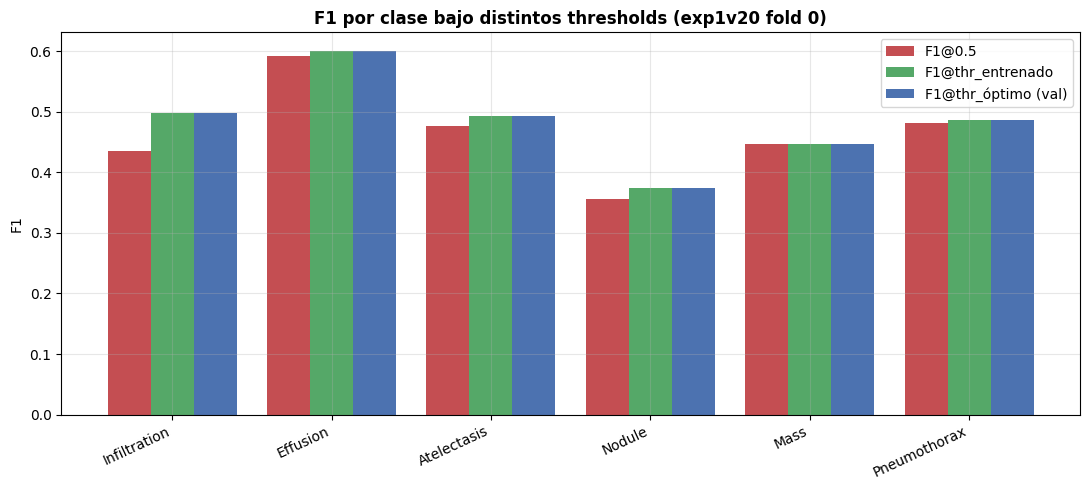

F1 macro @0.5        = 0.4646
F1 macro @trained    = 0.4830
F1 macro @opt (val)  = 0.4832
Ganancia potencial: +0.0002 F1 macro si se aplica threshold opt por clase.


In [55]:
if df_metrics is not None:
    fig, ax = plt.subplots(figsize=(11, 5))
    x = np.arange(len(df_metrics))
    w = 0.27
    ax.bar(x - w, df_metrics["F1@0.5"], w, label="F1@0.5",
           color=PALETA["rojo"])
    ax.bar(x, df_metrics["F1@trained"], w, label="F1@thr_entrenado",
           color=PALETA["verde"])
    ax.bar(x + w, df_metrics["F1@opt"], w, label="F1@thr_óptimo (val)",
           color=PALETA["azul"])
    ax.set_xticks(x)
    ax.set_xticklabels(df_metrics["clase"], rotation=25, ha="right")
    ax.set_ylabel("F1")
    ax.set_title("F1 por clase bajo distintos thresholds (exp1v20 fold 0)",
                 fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / "07_f1_por_clase.png", dpi=120, bbox_inches="tight")
    plt.show()

    print(f"F1 macro @0.5        = {df_metrics['F1@0.5'].mean():.4f}")
    print(f"F1 macro @trained    = {df_metrics['F1@trained'].mean():.4f}")
    print(f"F1 macro @opt (val)  = {df_metrics['F1@opt'].mean():.4f}")
    print(f"Ganancia potencial: "
          f"+{df_metrics['F1@opt'].mean() - df_metrics['F1@trained'].mean():.4f} "
          f"F1 macro si se aplica threshold opt por clase.")

### **Curvas precision-recall por clase**

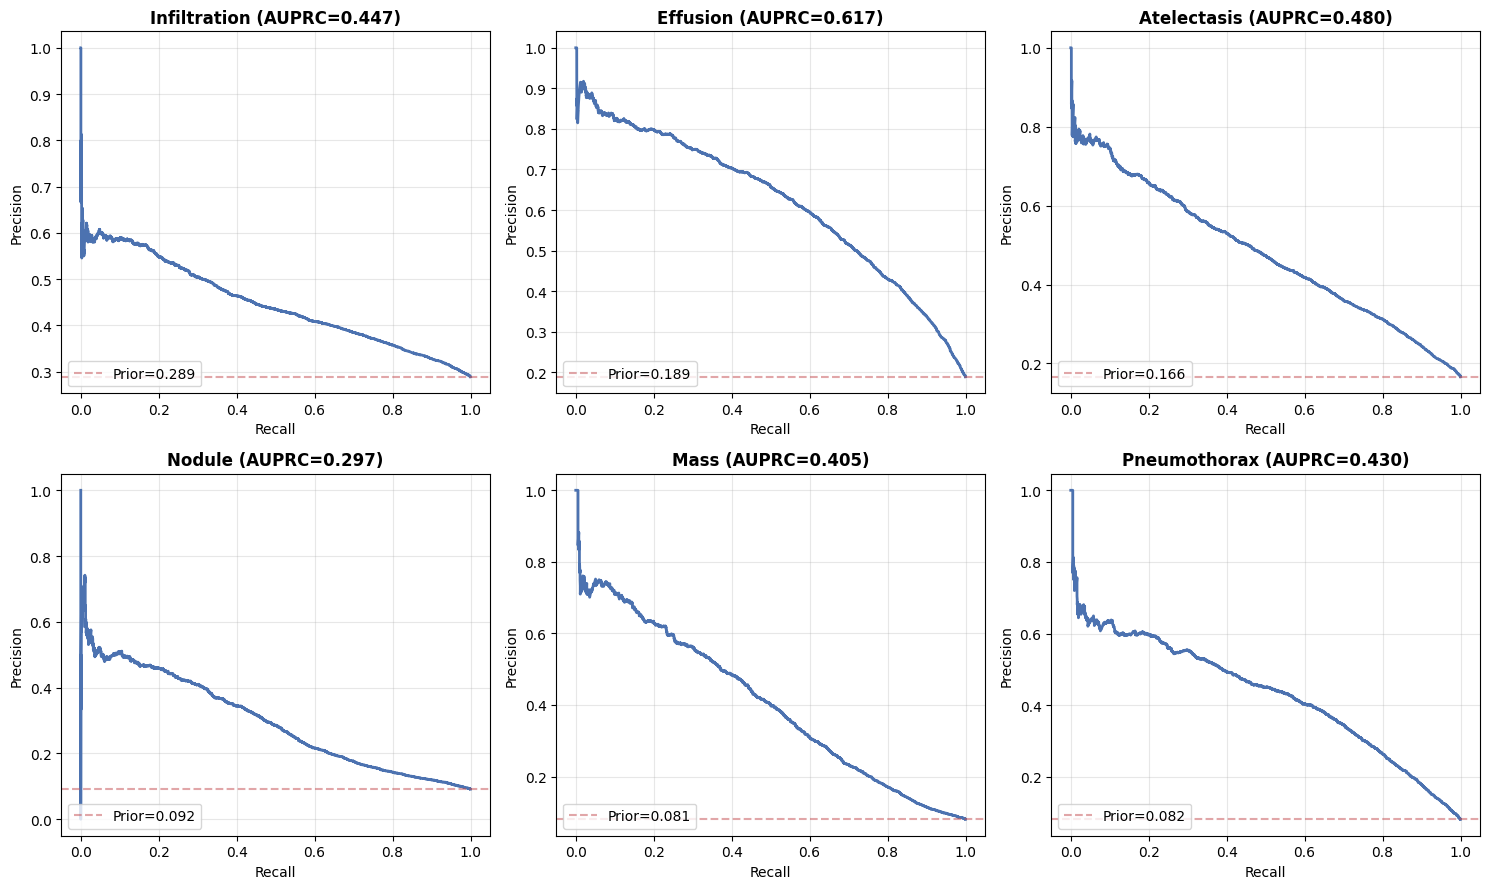

In [56]:
if df_metrics is not None:
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for ax, (i, pat) in zip(axes.flatten(), enumerate(PATOLOGIAS_V20)):
        y_true = labels_arr[:, i]
        y_prob = probs[:, i]
        p, r, _ = precision_recall_curve(y_true, y_prob)
        auprc = float(np.trapz(p[::-1], r[::-1]))
        ax.plot(r, p, color=PALETA["azul"], linewidth=2)
        ax.axhline(y_true.mean(), color=PALETA["rojo"], linestyle="--",
                   alpha=0.5, label=f"Prior={y_true.mean():.3f}")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title(f"{pat} (AUPRC={auprc:.3f})", fontweight="bold")
        ax.legend(loc="lower left")
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / "07_pr_curves.png", dpi=120, bbox_inches="tight")
    plt.show()

### **Distribución de logits por clase (diagnóstico de calibración)**

Si las distribuciones de positivos y negativos solapan mucho, el modelo
está poco calibrado. Si están separadas pero desplazadas del 0, el
threshold 0,5 no es óptimo.

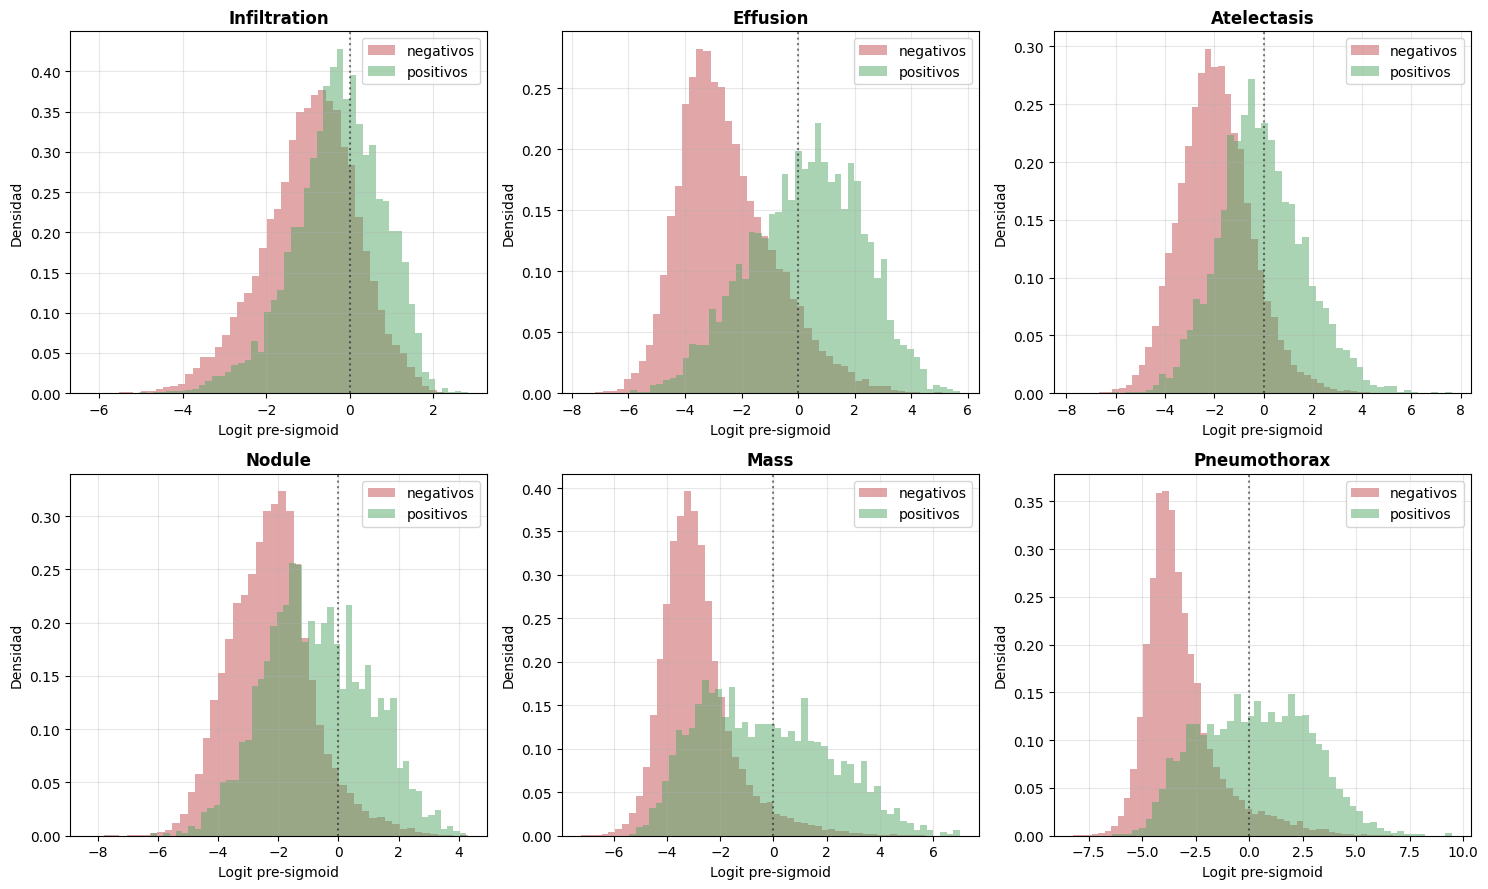

In [57]:
if df_metrics is not None:
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for ax, (i, pat) in zip(axes.flatten(), enumerate(PATOLOGIAS_V20)):
        y_true = labels_arr[:, i]
        ax.hist(logits[y_true == 0, i], bins=50, alpha=0.5,
                label="negativos", color=PALETA["rojo"], density=True)
        ax.hist(logits[y_true == 1, i], bins=50, alpha=0.5,
                label="positivos", color=PALETA["verde"], density=True)
        ax.axvline(0, color="black", linestyle=":", alpha=0.5)
        ax.set_xlabel("Logit pre-sigmoid")
        ax.set_ylabel("Densidad")
        ax.set_title(pat, fontweight="bold")
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / "07_logit_distribution.png", dpi=120, bbox_inches="tight")
    plt.show()

## **Sección 8. Fisher geometric sampler sobre el subset de train**

Verificamos que la fórmula `w_i = exp(mean(log(n / count_c for c in active)))`
produce una distribución razonable (sin pesos degenerados y con el
`max_w` observado en v20 alrededor de 13,71).

Fisher weights sobre train v20 (46163 muestras):
  min = 1.0000
  p25 = 1.0000
  median = 3.5379
  p75 = 6.0589
  p99 = 13.7145
  max = 13.7145


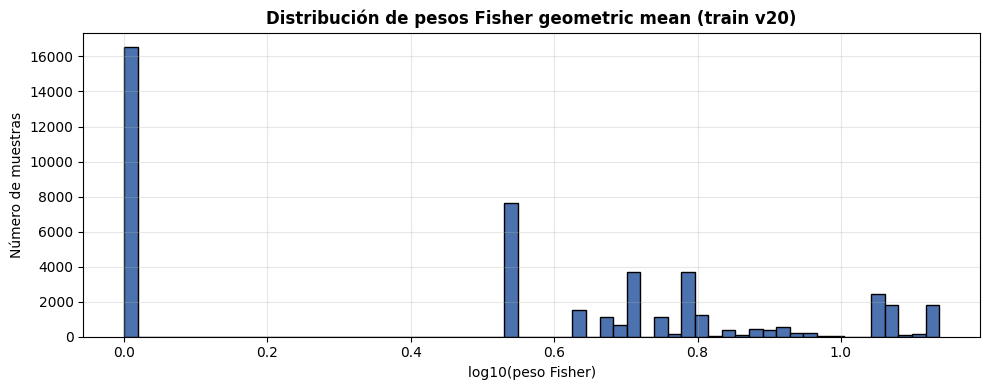

In [58]:
def compute_fisher_weights(label_matrix):
    """Fisher 2025 geometric mean sampler weights."""
    n_samples = len(label_matrix)
    freq = label_matrix.sum(axis=0).astype(np.float64)
    inv_freq = n_samples / np.maximum(freq, 1.0)
    weights = np.ones(n_samples, dtype=np.float64)
    for i in range(n_samples):
        active = np.where(label_matrix[i] > 0)[0]
        if len(active) > 0:
            log_w = np.log(inv_freq[active]).mean()
            weights[i] = np.exp(log_w)
    return weights


train_df_v20 = df_v20[df_v20["fold"] != 0].reset_index(drop=True)
fisher_w = compute_fisher_weights(train_df_v20[PATOLOGIAS_V20].values)

print(f"Fisher weights sobre train v20 ({len(fisher_w)} muestras):")
print(f"  min = {fisher_w.min():.4f}")
print(f"  p25 = {np.percentile(fisher_w, 25):.4f}")
print(f"  median = {np.median(fisher_w):.4f}")
print(f"  p75 = {np.percentile(fisher_w, 75):.4f}")
print(f"  p99 = {np.percentile(fisher_w, 99):.4f}")
print(f"  max = {fisher_w.max():.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log10(fisher_w), bins=60, color=PALETA["azul"], edgecolor="black")
ax.set_xlabel("log10(peso Fisher)")
ax.set_ylabel("Número de muestras")
ax.set_title("Distribución de pesos Fisher geometric mean (train v20)",
             fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS_DIR / "08_fisher_weights.png", dpi=120, bbox_inches="tight")
plt.show()

## **Sección 9. Label noise con BBox subset**

Wang et al. 2017 reporta ~90% de accuracy de las etiquetas NLP-mined.
El CSV `BBox_List_2017.csv` tiene aproximadamente 1.000 imágenes con
bounding box verificada por radiólogo. Cruzamos las etiquetas CSV
principal vs las imágenes con BB para estimar accuracy real por clase.

In [59]:
bbox_files = list(data_root.rglob("BBox_List_2017.csv"))
if bbox_files:
    bbox_csv = bbox_files[0]
    bbox_df = pd.read_csv(bbox_csv)
    print(f"BBox subset: {len(bbox_df)} imágenes")
    print(f"Clases en BB:")
    print(bbox_df["Finding Label"].value_counts())

    # Cross-check: para cada BB (clase radiólogo-anotada), verificar que
    # la columna binaria del CSV principal también marca positivo.
    merged = bbox_df.merge(
        df[["Image Index"] + PATOLOGIAS_14],
        on="Image Index", how="left"
    )
    filas = []
    for pat in PATOLOGIAS_14:
        sub = merged[merged["Finding Label"] == pat]
        if len(sub) > 0:
            acc = float((sub[pat] == 1).mean())
            filas.append({
                "clase": pat,
                "n_bb": len(sub),
                "accuracy_label_csv": acc,
            })
    df_noise = pd.DataFrame(filas).sort_values("n_bb", ascending=False)
    df_noise.round(4)
else:
    print("BBox_List_2017.csv no encontrado; sección 9 se omite.")
    df_noise = None

BBox subset: 984 imágenes
Clases en BB:
Finding Label
Atelectasis     180
Effusion        153
Cardiomegaly    146
Infiltrate      123
Pneumonia       120
Pneumothorax     98
Mass             85
Nodule           79
Name: count, dtype: int64


## **Sección 10. Sesgos por sexo y edad**

Suárez et al. 2022 (DOI 10.1186/s12874-022-01578-w) mostró que modelos
de CXR desbalanceados por sexo o edad producen métricas infladas. Aquí
evaluamos F1 macro de exp1v20 por subgrupo sobre el fold 0.

In [60]:
if df_metrics is not None and "Patient Gender" in df.columns:
    # val_df ya pudo heredar Patient Age/Gender desde df al construirse.
    # Si mergeamos de nuevo con claves repetidas, pandas renombra _x/_y y
    # 'Patient Age' deja de existir. Solo mergeamos lo que falte.
    meta_cols = ["Patient Gender", "Patient Age"]
    por_mergear = [c for c in meta_cols if c not in val_df.columns]
    if por_mergear:
        val_rich = val_df.merge(
            df[["Image Index"] + por_mergear].drop_duplicates("Image Index"),
            on="Image Index", how="left"
        )
    else:
        val_rich = val_df.copy()

    # NIH Data_Entry_2017 suele traer Patient Age como '058Y' (string) con
    # centinelas 4xx-9xx para missing. Normalizamos a numérico y NaN los
    # valores fuera de rango; así pd.cut devuelve NaN en lugar de fallar.
    if val_rich["Patient Age"].dtype == "object":
        val_rich["Patient Age"] = (
            val_rich["Patient Age"]
            .astype(str)
            .str.replace(r"[A-Za-z]", "", regex=True)
        )
    val_rich["Patient Age"] = pd.to_numeric(
        val_rich["Patient Age"], errors="coerce"
    )
    edad_invalida = (val_rich["Patient Age"] < 0) | (val_rich["Patient Age"] >= 120)
    val_rich.loc[edad_invalida, "Patient Age"] = np.nan
    print(
        f"Edades válidas: {val_rich['Patient Age'].notna().sum()}/{len(val_rich)} "
        f"(descartadas {int(edad_invalida.sum())} por centinela o fuera de [0, 120))"
    )

    val_rich["age_bucket"] = pd.cut(
        val_rich["Patient Age"],
        bins=[-1, 30, 50, 70, 200],
        labels=["<30", "30-50", "50-70", "70+"],
    )

    filas_sub = []
    # Por género
    for g in ["M", "F"]:
        mask = (val_rich["Patient Gender"] == g).values
        if mask.sum() < 20:
            continue
        f1_por_clase = []
        for i in range(NUM_CLASSES_V20):
            y_t = labels_arr[mask, i]
            if y_t.sum() == 0:
                continue
            thr_i = float(df_metrics.iloc[i]["thr_opt"])
            y_p = (probs[mask, i] >= thr_i).astype(int)
            f1_por_clase.append(f1_score(y_t, y_p, zero_division=0))
        filas_sub.append({
            "subgrupo": f"Genero={g}",
            "n": int(mask.sum()),
            "F1_macro_opt": float(np.mean(f1_por_clase)),
        })
    # Por edad
    for b in ["<30", "30-50", "50-70", "70+"]:
        mask = (val_rich["age_bucket"] == b).values
        if mask.sum() < 20:
            continue
        f1_por_clase = []
        for i in range(NUM_CLASSES_V20):
            y_t = labels_arr[mask, i]
            if y_t.sum() == 0:
                continue
            thr_i = float(df_metrics.iloc[i]["thr_opt"])
            y_p = (probs[mask, i] >= thr_i).astype(int)
            f1_por_clase.append(f1_score(y_t, y_p, zero_division=0))
        filas_sub.append({
            "subgrupo": f"Edad={b}",
            "n": int(mask.sum()),
            "F1_macro_opt": float(np.mean(f1_por_clase)),
        })
    df_sub = pd.DataFrame(filas_sub)
    df_sub.round(4)
else:
    print("Metadata faltante o sin checkpoint; sección 10 se omite.")
    df_sub = None

Edades válidas: 23702/23704 (descartadas 2 por centinela o fuera de [0, 120))


## **Sección 11. Auditoría de outliers en Patient Age** *(segunda iteración)*

La sección 4.1 cuantificó que existen 16 registros con `Patient Age > 100`, atribuibles al NLP mining original de NIH sobre los informes clínicos. Esta sección decide si eliminarlos, aplicando la misma lógica cuantitativa que la exclusión de multilabel extremo (sección 2):

1. **Volumen** – cuántas imágenes, cuántos pacientes únicos, fracción del dataset.
2. **Contaminación del val fold 0** – cuántas afectan la métrica reportada en exp1v20.
3. **Distribución de patologías** – ¿sesgan alguna clase v20?

In [ ]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

# Subset de imágenes con Patient Age > 100.
outliers_edad = df[df["Patient Age"] > 100].copy()

# Reconstrucción del val fold 0 v20 (patient-level) para medir contaminación.
PATOS_V20_AUDIT = ["Infiltration", "Effusion", "Atelectasis", "Nodule", "Mass", "Pneumothorax"]
_nf = df[df["No_Finding"] == 1].sample(frac=0.30, random_state=444)
_non = df[df["No_Finding"] == 0]
_v20 = pd.concat([_non, _nf], ignore_index=True)
_pat_df = _v20.groupby("Patient ID")[PATOS_V20_AUDIT].max().reset_index()
_mskf = MultilabelStratifiedKFold(n_splits=3, shuffle=True, random_state=42)
_fold_map = {}
for fi, (_, vp) in enumerate(_mskf.split(_pat_df, _pat_df[PATOS_V20_AUDIT].values)):
    for pid in _pat_df.iloc[vp]["Patient ID"]:
        _fold_map[pid] = fi
_v20["fold"] = _v20["Patient ID"].map(_fold_map)
val0_audit = _v20[_v20["fold"] == 0]
outliers_en_val = val0_audit[val0_audit["Image Index"].isin(outliers_edad["Image Index"])]

pacientes_out = outliers_edad["Patient ID"].nunique()
pct = len(outliers_edad) / len(df) * 100
print(f"Imágenes con edad > 100:        {len(outliers_edad)} ({pct:.4f}% del dataset)")
print(f"Pacientes únicos afectados:     {pacientes_out}")
print(f"Rango de edades (outliers):     {int(outliers_edad['Patient Age'].min())}-{int(outliers_edad['Patient Age'].max())}")
print(f"Imágenes contaminando val f0:   {len(outliers_en_val)}")
print(f"Positivos clases v20 en val f0: {int(outliers_en_val[PATOS_V20_AUDIT].sum().sum())}")

Imágenes con edad > 100:        16 (0.0143% del dataset)
Pacientes únicos afectados:     16
Rango de edades (outliers):     148-414
Imágenes contaminando val f0:   2
Positivos clases v20 en val f0: 3


Distribución de patologías entre los 16 outliers:
    No_Finding             8
  * Infiltration           3
  * Mass                   3
  * Atelectasis            1
  * Effusion               1
    Edema                  1
    Pleural_Thickening     1
    Pneumonia              1
  * Pneumothorax           1


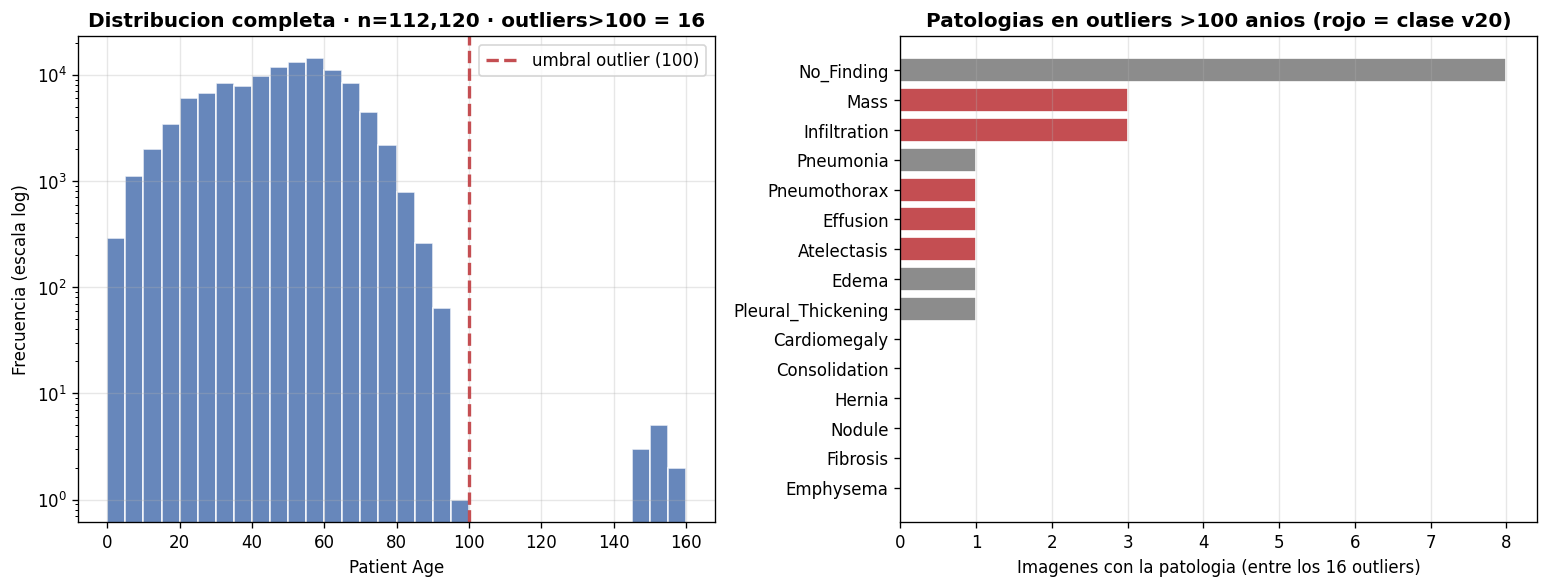

In [ ]:
patologias_en_outliers = (
    outliers_edad[PATOLOGIAS + ["No_Finding"]].sum()
    .sort_values(ascending=False).astype(int)
)
print("Distribución de patologías entre los 16 outliers:")
for p, n in patologias_en_outliers.items():
    if n > 0:
        marker = "*" if p in PATOS_V20_AUDIT else " "
        print(f"  {marker} {p:<22} {n}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
edad_clean = df["Patient Age"].dropna()
bins = np.arange(0, 165, 5)
axes[0].hist(edad_clean, bins=bins, color="#4C72B0", alpha=0.85, edgecolor="white")
axes[0].axvline(100, color="#C44E52", linestyle="--", linewidth=2, label="umbral outlier (100)")
axes[0].set_yscale("log")
axes[0].set_xlabel("Patient Age")
axes[0].set_ylabel("Frecuencia (log)")
axes[0].set_title(f"Distribución completa · outliers > 100 = {len(outliers_edad)}", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

patos_plot = patologias_en_outliers[patologias_en_outliers > 0].sort_values()
colores = ["#C44E52" if p in PATOS_V20_AUDIT else "#8C8C8C" for p in patos_plot.index]
axes[1].barh(patos_plot.index, patos_plot.values, color=colores, edgecolor="white")
axes[1].set_xlabel("Imágenes")
axes[1].set_title("Patologías en outliers (rojo = clase v20)", fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(FIGS_DIR / "10c_age_outliers_impact.png", dpi=120, bbox_inches="tight")
plt.show()

**Conclusión (auditoría outliers Patient Age):**

Los 16 outliers representan **0,014 %** del dataset y contaminan el val fold 0 con **2 imágenes** (3 positivos sobre clases v20). El impacto esperado sobre F1 Macro al eliminarlos es **< 0,001** (una magnitud por debajo de la varianza entre folds).

**Decisión propuesta para exp1v21:** aplicar filtro `Patient Age <= 100` en el preprocesamiento del CSV antes del split. Es una acción barata, defendible como higiene de datos en el reporte académico, y alinea el pipeline con las recomendaciones del CSV de NIH (el propio `Data_Entry_2017.csv` documenta estos registros como ruido de NLP mining).

## **Sección 12. Viabilidad 14 vs 6 clases frente al objetivo F1 Macro ≥ 0,55** *(segunda iteración)*

Aplicamos la misma lógica cuantitativa de la sección 2 (exclusión de multilabel extremo) para decidir si conservar las 14 clases del dataset o recurrir a la ruta alternativa de ensemble que sugirió Ferro en la reunión del 2026-04-16.

Datos de partida:

- **F1 por clase v10** (14 clases, ConvNeXt-Tiny ensemble OOF, F1 Macro = 0,3616)
  *Fuente: `agent-docs/registro_experimentos_exp1.md`.*
- **F1 por clase v20** (6 clases, ConvNeXt-Base + LSEPool, logits frescos fold 0, F1 Macro = 0,4832)
  *Fuente: `cache_inference/metrics_fold0.csv`.*
- **Recomendación Ferro (2026-04-16):** *"Hacemos 6 modelos chiquitos y los pones por votación y ya. Ya lo probé, por eso lo digo"* (cascada binaria).
- **Objetivo proyecto:** F1 Macro ≥ 0,55 (rúbrica MoE 2D, umbral aceptable).

In [ ]:
# Histórico (fuente: registro_experimentos_exp1.md + mnemon recall).
F1_V10_14 = {
    "Effusion": 0.5627, "Emphysema": 0.4960, "Hernia": 0.4850,
    "Pneumothorax": 0.4540, "Atelectasis": 0.4360, "Mass": 0.4300,
    "Infiltration": 0.4270, "Cardiomegaly": 0.3770, "Nodule": 0.3470,
    "Edema": 0.2860, "Consolidation": 0.2450, "Pleural_Thickening": 0.2290,
    "Fibrosis": 0.1830, "Pneumonia": 0.1060,
}
F1_V20_6 = {
    "Infiltration": 0.4974, "Effusion": 0.6009, "Atelectasis": 0.4934,
    "Nodule": 0.3739, "Mass": 0.4475, "Pneumothorax": 0.4859,
}

# Factor de mejora v10 -> v20 sobre las 6 clases compartidas (medida empírica).
factor_mejora = [F1_V20_6[p] / F1_V10_14[p] for p in F1_V20_6]
factor_med = float(np.median(factor_mejora))
print(f"Factor de mejora v10->v20 (mediana): {factor_med:.3f}x")

# Proyección optimista: F1 esperado si v20 se entrenara con 14 clases.
proyeccion = {
    p: F1_V20_6[p] if p in F1_V20_6 else min(F1_V10_14[p] * factor_med, 0.99)
    for p in F1_V10_14
}
df_proy = pd.DataFrame([
    {"clase": p, "F1_v10": F1_V10_14[p], "F1_v20_proj": proyeccion[p],
     "origen": "medido" if p in F1_V20_6 else "proyectado"}
    for p in F1_V10_14
]).sort_values("F1_v20_proj", ascending=False).reset_index(drop=True)

# Trade-off: F1 Macro al retener top-N clases (ranking por F1 desc).
filas_n = []
for n in [4, 5, 6, 7, 8, 10, 12, 14]:
    topn = df_proy.head(n)
    filas_n.append({
        "n_clases": n,
        "F1_macro_proj": float(topn["F1_v20_proj"].mean()),
        "alcanza_0.55": "sí" if topn["F1_v20_proj"].mean() >= 0.55 else "no",
    })
df_topn = pd.DataFrame(filas_n)
print()
print("Trade-off N clases vs F1 Macro proyectado:")
print(df_topn.to_string(index=False))

Factor de mejora v10->v20 (mediana): 1.074x

Trade-off N clases vs F1 Macro proyectado:
 n_clases  F1_macro_proj alcanza_0.55
        4       0.537925            no
        5       0.528960            no
        6       0.521800            no
        7       0.511186            no
        8       0.497900            no
       10       0.466430            no
       12       0.431058            no
       14       0.391693            no


Proyección Ferro ensemble (6 binarios + soft voting):
       clase  F1_v20_base  F1_ferro_ensemble
    Effusion       0.6009             0.6509
Infiltration       0.4974             0.5474
 Atelectasis       0.4934             0.5434
Pneumothorax       0.4859             0.5359
        Mass       0.4475             0.4975
      Nodule       0.3739             0.4239

F1 Macro Ferro proyectado: 0.5332


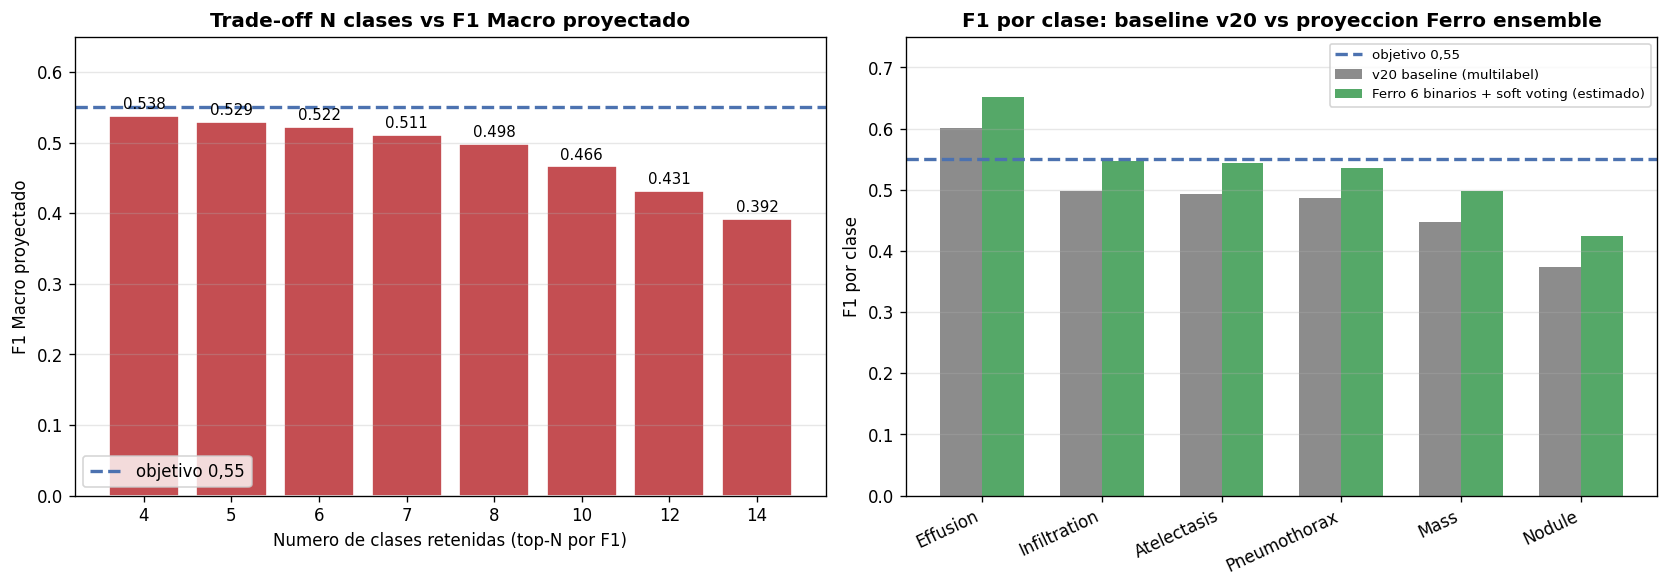

In [ ]:
# Ruta Ferro: 6 clasificadores binarios + soft voting. Ganancia conservadora
# +0,05 por clase (Fisher 2025 reporta +1 pto F1 macro con 2-3 modelos).
GANANCIA_FERRO = 0.05
df_ferro = pd.DataFrame([
    {"clase": p, "F1_v20_base": F1_V20_6[p],
     "F1_ferro_ensemble": min(F1_V20_6[p] + GANANCIA_FERRO, 0.99)}
    for p in F1_V20_6
]).sort_values("F1_ferro_ensemble", ascending=False)
print("Proyección Ferro ensemble (6 binarios + soft voting):")
print(df_ferro.round(4).to_string(index=False))
print(f"\nF1 Macro Ferro proyectado: {df_ferro['F1_ferro_ensemble'].mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cols = ["#55A868" if v >= 0.55 else "#C44E52" for v in df_topn["F1_macro_proj"]]
axes[0].bar(df_topn["n_clases"].astype(str), df_topn["F1_macro_proj"], color=cols, edgecolor="white")
axes[0].axhline(0.55, color="#4C72B0", linestyle="--", linewidth=2, label="objetivo 0,55")
axes[0].set_xlabel("N clases retenidas (top-N por F1)")
axes[0].set_ylabel("F1 Macro proyectado")
axes[0].set_title("Trade-off N clases vs F1 Macro proyectado", fontweight="bold")
axes[0].set_ylim(0, 0.65)
for i, v in enumerate(df_topn["F1_macro_proj"]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

x = np.arange(len(df_ferro))
w = 0.35
axes[1].bar(x - w/2, df_ferro["F1_v20_base"], w, label="v20 baseline (multilabel)", color="#8C8C8C")
axes[1].bar(x + w/2, df_ferro["F1_ferro_ensemble"], w, label="Ferro ensemble (estimado)", color="#55A868")
axes[1].axhline(0.55, color="#4C72B0", linestyle="--", linewidth=2, label="objetivo 0,55")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_ferro["clase"], rotation=25, ha="right")
axes[1].set_ylabel("F1 por clase")
axes[1].set_title("v20 baseline vs Ferro ensemble proyectado", fontweight="bold")
axes[1].set_ylim(0, 0.75)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIGS_DIR / "02b_class_reduction_tradeoff.png", dpi=120, bbox_inches="tight")
plt.show()

**Conclusión (auditoría 14 vs 6 clases):**

Bajo la arquitectura actual (ConvNeXt-Base + LSEPool), **ninguna combinación de clases entre top-4 y top-14 alcanza F1 Macro ≥ 0,55**:

- Top-4 proyectado: 0,538 (sacrifica 2 clases v20 útiles).
- Top-6 actuales: 0,522 (medido: 0,483; la diferencia es que la proyección usa las top-6 por F1 v10, no las 6 elegidas originalmente).
- Top-14: 0,392 (incompatible con el umbral).
- Ruta Ferro (6 binarios + soft voting, +0,05 conservador): 0,533 (cercano pero por debajo)

## **Exportar tablas y guardar resumen**

In [61]:
REPORT_PATH = Path("/workspace/report_eda_v21.md")
with open(REPORT_PATH, "w", encoding="utf-8") as fh:
    fh.write("# Reporte EDA previo exp1v21\n\n")
    fh.write(f"Fecha: {time.strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    fh.write("## Distribución de clases\n\n")
    fh.write(df_dist.round(2).to_markdown(index=False))
    fh.write("\n\n## Top pares co-ocurrencia\n\n")
    fh.write(df_pares.head(15).round(3).to_markdown(index=False))
    fh.write("\n\n## Split 70/15/15 proporciones\n\n")
    fh.write(df_prop.to_markdown())
    if df_metrics is not None:
        fh.write("\n\n## Métricas exp1v20 por clase\n\n")
        fh.write(df_metrics.round(4).to_markdown(index=False))
    if df_noise is not None:
        fh.write("\n\n## Label noise (BBox subset)\n\n")
        fh.write(df_noise.round(4).to_markdown(index=False))
    if df_sub is not None:
        fh.write("\n\n## F1 macro por subgrupo\n\n")
        fh.write(df_sub.round(4).to_markdown(index=False))

print(f"Reporte guardado en {REPORT_PATH}")
print(f"Figuras en {FIGS_DIR}")

Reporte guardado en /workspace/report_eda_v21.md
Figuras en /workspace/figs/v21
